In [2]:
from llm_consistency.core.paths import ProjectPaths
from llm_consistency.datasets.registry import get_dataset_spec
import pandas as pd

dataset = "SimpleQA"
experiment_flag = "v00"
temperature = 0.0

paths = ProjectPaths()
rp = paths.run_paths(dataset, experiment_flag)
conf = rp.conf_suffix(temperature=temperature)

d = pd.read_csv(rp.answers_all_models_file("both", conf))


df = pd.read_csv(rp.grades_all_judges_file("both"))


# print(d.shape)
print(df.shape)
with pd.option_context(
    'display.max_colwidth', None,
    'display.max_columns', None,
    'display.expand_frame_repr', False
):
    # display(df1[(df1.idx == 1499) & (df1.model == "gpt-3.5-turbo")])
    # display(df1)
    pass


(694868, 12)


In [3]:
df.idx.nunique()

1129

In [4]:
import pandas as pd

def aggregate_judges_list_based(df):
    qid_cols = ["model", "idx", "paraphrased_question"]

    grouped = (
        df
        .groupby(qid_cols)
        .agg(
            original_question=("original_question", "first"),
            verdicts=("verdict", list),
            evaluators=("evaluator", list),
        )
        .reset_index()
    )

    # ---- overall stats ----
    def overall_stats(vs):
        vc = pd.Series(vs).value_counts()
        return pd.Series({
            "num_judges": len(vs),
            "num_unique": vc.size,
            "all_same": vc.size == 1,
            "max_agreement_count": vc.max(),
            "max_agreement_value": vc.idxmax(),
        })

    grouped[[
        "num_judges",
        "num_unique",
        "all_same",
        "max_agreement_count",
        "max_agreement_value",
    ]] = grouped["verdicts"].apply(overall_stats)

    # ---- GPT-only stats ----
    def gpt_stats(row):
        gpt_verdicts = [
            v for v, e in zip(row["verdicts"], row["evaluators"])
            if "gpt" in e
        ]

        if len(gpt_verdicts) == 0:
            return pd.Series({
                "gpt_num_judges": 0,
                "gpt_num_unique": pd.NA,
                "gpt_agree": pd.NA,
                "gpt_max_agreement_count": pd.NA,
                "gpt_max_agreement_value": pd.NA,
            })

        vc = pd.Series(gpt_verdicts).value_counts()
        return pd.Series({
            "gpt_num_judges": len(gpt_verdicts),
            "gpt_num_unique": vc.size,
            "gpt_agree": vc.size == 1,
            "gpt_max_agreement_count": vc.max(),
            "gpt_max_agreement_value": vc.idxmax(),
        })

    grouped[[
        "gpt_num_judges",
        "gpt_num_unique",
        "gpt_agree",
        "gpt_max_agreement_count",
        "gpt_max_agreement_value",
    ]] = grouped.apply(gpt_stats, axis=1)

    return grouped.drop(columns="verdicts")

agg = aggregate_judges_list_based(df)

print(agg.shape)


(173717, 15)


In [5]:
from analysis_utils import df_to_acl_icml_table, prep_for_paper, prep, model_name_map

In [6]:


df = agg.copy()
print(df.shape)
df = df[df.gpt_agree & (df.max_agreement_count >= 2)]
print(df.shape)
evals = df.copy()
df = agg.copy()
vo = df[df.original_question == df.paraphrased_question].copy()   # from original_only group
vp = df[df.original_question != df.paraphrased_question].copy()  # from paraphrased_only group
print(vo.shape, vp.shape)
vo = vo[vo.gpt_agree & (vo.max_agreement_count >= 2)]
vp = vp[vp.gpt_agree & (vp.max_agreement_count >= 2)]
print(vo.shape, vp.shape)
# print(vo.columns)
# vo = vo[vo.gpt_agree & (vo.max_agreement_count >= 5)]
# vp = vp[vp.gpt_agree & (vp.max_agreement_count >= 5)]
# print(vo.shape, vp.shape)

(173717, 15)
(158161, 15)
(21451, 15) (152266, 15)
(19835, 15) (138326, 15)


## HERE the actual analysis begins!

In [7]:
def original_distribution(df_orig, col="max_agreement_value", suffix="_orig"):
    """
    df_orig: verdicts_original (one row per (idx, model))
    Returns: DataFrame indexed by (idx, model) with columns A_orig, B_orig, C_orig
    """
    dist = pd.get_dummies(df_orig[col]) #\
            #    .reindex(columns=["A", "B", "C"], fill_value=0)

    # dist.columns = [c + "_orig" for c in dist.columns]
    dist.columns = dist.columns.astype(str) + suffix

    # Set multi-index (idx, model) for alignment with paraphrased
    dist["idx"] = df_orig["idx"]
    dist["model"] = df_orig["model"]
    return dist.set_index(["idx", "model"])

def paraphrased_distribution(df_para, col="max_agreement_value", suffix="_para"):
    """
    df_para: verdicts_paraphrased (many rows per (idx, model))
    Returns: normalized distribution per (idx, model) with A_para, B_para, C_para
    """
    norm = (
        df_para.groupby(["idx", "model"])[col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        # .reindex(columns=["A", "B", "C"], fill_value=0)
    )

    # normalize row-wise inside each (idx, model)
    # norm = counts.div(counts.sum(axis=1), axis=0)
    # norm.columns = [c + suffix for c in norm.columns]
    norm.columns = norm.columns.astype(str) + suffix

    return norm

import numpy as np
def iid_mismatch_metric(group, col="max_agreement_value", suffix=""):
    p = group[col].value_counts(normalize=True)
    iid_mismatch_prob = 1 - (p ** 2).sum()
    distinct_answers = p.size
    mode_share = p.max()
    entropy = -(p * np.log(p)).sum()

    res = {
        "iid_mismatch_prob": iid_mismatch_prob,
        "distinct_classes": int(distinct_answers), # this is the number of distinct answers or labels
        "mode_share": mode_share,
        "entropy": entropy,
        "num_paraphrases": len(group),
        "normalized_entropy": entropy / np.log(len(group)) if len(group) > 1 else 0.0,
    }
    if suffix:
        res = {k + suffix: v for k, v in res.items()}
    return pd.Series(res)


In [8]:
vpp = pd.concat([vp, vo], ignore_index=True)
orig_dist = original_distribution(vo)
para_dist = paraphrased_distribution(vp)
para_dist2 = vp.groupby(["idx", "model"])[["max_agreement_value"]].apply(iid_mismatch_metric)
# para_dist2 = vp.groupby(["idx", "model"])["max_agreement_value"].apply(iid_mismatch_metric_df)
para_dist2["distinct_classes"] = para_dist2["distinct_classes"].astype("int64")
para_dist2["num_paraphrases"] = para_dist2["num_paraphrases"].astype("int64")

su = "_both"
both_dist = paraphrased_distribution(vpp, suffix=su)
both_dist2 = vpp.groupby(["idx", "model"])[["max_agreement_value"]].apply(iid_mismatch_metric, suffix=su)
both_dist2["distinct_classes"+su] = both_dist2["distinct_classes"+su].astype("int64")
both_dist2["num_paraphrases"+su] = both_dist2["num_paraphrases"+su].astype("int64")


print(orig_dist.shape, para_dist.shape, para_dist2.shape, both_dist.shape, both_dist2.shape)

# merged_dist = orig_dist.join(para_dist, how="inner")
merged = (
    orig_dist
    .join(para_dist, how="inner")
    .join(para_dist2, how="inner")
)
merged2 = (
    orig_dist
    .join(para_dist, how="inner")
    .join(para_dist2, how="inner")
    .join(both_dist, how="inner")
    .join(both_dist2, how="inner")
)
print(merged.shape, merged2.shape)
aligned = merged.copy()
aligned = merged2.copy()
print(aligned.columns)
for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    cols = [label + subset for label in labels]

    aligned[f"{subset}_label"] = merged2[cols].idxmax(axis=1).str.replace(f"_{subset}", "")
    vals = merged2[cols]

    row_max = vals.max(axis=1)
    num_max = vals.eq(row_max, axis=0).sum(axis=1)

    # aligned[f"{subset}_label"] = np.where(
    #     num_max == 1,
    #     vals.idxmax(axis=1).str.replace(f"_{subset}", ""),
    #     "tie"
    # )

    aligned[f"{subset}_is_tie"] = num_max > 1
    def tied_labels(row):
        m = row.max()
        return tuple(
            c.replace(f"_{subset}", "")
            for c in cols if row[c] == m
        )

    aligned[f"{subset}_tied_labels"] = merged2[cols].apply(tied_labels, axis=1)


# aligned["orig_label"] = merged[["A_orig", "B_orig", "C_orig"]].idxmax(axis=1).str.replace("_orig", "")
# aligned["para_label"] = merged[["A_para", "B_para", "C_para"]].idxmax(axis=1).str.replace("_para", "")
# aligned["both_label"] = merged2[["A_both", "B_both", "C_both"]].idxmax(axis=1).str.replace("_both", "")
aligned["match"] = aligned["orig_label"] == aligned["para_label"]
# aligned["match_"] = aligned["orig_label"] == aligned["both_label"]
print(aligned.shape)


(19835, 3) (21360, 3) (21360, 6) (21403, 3) (21403, 6)
(19792, 12) (19792, 21)
Index(['correct_orig', 'incorrect_orig', 'not_attempted_orig', 'correct_para',
       'incorrect_para', 'not_attempted_para', 'iid_mismatch_prob',
       'distinct_classes', 'mode_share', 'entropy', 'num_paraphrases',
       'normalized_entropy', 'correct_both', 'incorrect_both',
       'not_attempted_both', 'iid_mismatch_prob_both', 'distinct_classes_both',
       'mode_share_both', 'entropy_both', 'num_paraphrases_both',
       'normalized_entropy_both'],
      dtype='object')
(19792, 31)


### Load or Save

In [9]:
import pandas as pd
dataset = "SimpleQA"
intermediate_path = f"aligned_verdicts_{dataset}.pkl"

# Save
# aligned.reset_index().to_pickle(intermediate_path)

# Load
atemp = pd.read_pickle(intermediate_path)
aligned = atemp.set_index(['idx', 'model'])

# Now they'll match perfectly
atemp.equals(aligned.reset_index())  # True

True

In [10]:
# print(atemp.set_index(['idx', 'model']).equals(aligned))
# aligned = atemp.set_index(['idx', 'model'])

In [11]:
tie_stats = {}

for subset in ["orig", "para", "both"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    cols = [label + subset for label in labels]

    row_max = aligned[cols].max(axis=1)
    num_max = aligned[cols].eq(row_max, axis=0).sum(axis=1)

    tie_stats[subset] = {
        "num_rows": len(aligned),
        "num_ties": (num_max > 1).sum(),
        "tie_rate": (num_max > 1).mean(),
    }

tie_stats


{'orig': {'num_rows': 19747,
  'num_ties': np.int64(0),
  'tie_rate': np.float64(0.0)},
 'para': {'num_rows': 19747,
  'num_ties': np.int64(964),
  'tie_rate': np.float64(0.04881754190509951)},
 'both': {'num_rows': 19747,
  'num_ties': np.int64(735),
  'tie_rate': np.float64(0.03722084367245657)}}

In [12]:
aligned_prev = aligned.copy()
print(aligned_prev.shape)
# aligned = aligned[(~aligned["para_is_tie"]) & (~aligned["orig_is_tie"])]
# print(aligned.shape)
# aligned = aligned_prev
# print(aligned.shape)

(19747, 31)


In [13]:
from analysis_utils import df_to_acl_icml_table, prep_for_paper, prep, model_name_map

In [14]:
# import pandas as pd

# def sort_with_my_logic_(df, score_col="correct_orig", model_col="model"):
#     df = df.reset_index(drop=True)

#     is_qwen3 = df[model_col].str.contains("Qwen/Qwen3", na=False)
#     is_thinking = df[model_col].str.contains(r"\[with_thinking\]", na=False)
#     is_qwen3_8b = (
#         df[model_col].str.startswith("Qwen/Qwen3-8B", na=False)
#         & ~df[model_col].str.endswith("[with_thinking]", na=False)
#     )

#     df["_dup_anchor"] = False
#     dup = df[is_qwen3_8b].copy()
#     dup["_dup_anchor"] = True
#     df = pd.concat([df, dup], ignore_index=True)

#     qwen_block = df[model_col].str.contains("Qwen/Qwen3", na=False)
#     thinking = qwen_block & df[model_col].str.contains(r"\[with_thinking\]", na=False)

#     # <-- key line: duplicated anchor should behave like non-qwen in sorting
#     qwen_block = qwen_block & ~df["_dup_anchor"]

#     return (
#         df.assign(qwen_block=qwen_block, thinking=thinking)
#           .sort_values(["qwen_block", "thinking", score_col], ascending=[True, True, False])
#           .drop(columns=["qwen_block", "thinking", "_dup_anchor"])
#           .reset_index(drop=True)
#     )

# import re
# import pandas as pd

# def sort_with_my_logic(df: pd.DataFrame, model_col: str = "model", score_col: str = "correct_orig") -> pd.DataFrame:
#     df = df.copy()

#     # extract size in billions (0.6, 1.7, 7, 14, 32, 20, ...)
#     size_b = df[model_col].astype(str).str.extract(r"(\d+(?:\.\d+)?)\s*[Bb]\b")[0].astype(float)

#     # normalize name so thinking tag doesn't affect primary ordering
#     base = (
#         df[model_col].astype(str)
#         .str.replace(r"\[with_thinking\]", "", regex=True)
#         .str.strip()
#     )

#     return (
#         df.assign(_base=base, _size=size_b.fillna(float("inf")))
#           .sort_values(["_base", "_size"], ascending=[True, True])
#           .drop(columns=["_base", "_size"])
#           .reset_index(drop=True)
#     )

import re
import pandas as pd

def sort_with_my_logic(df: pd.DataFrame, model_col: str = "model", score_col="correct_orig") -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()

    s = df[model_col].astype(str)

    # ---- parse "size" like 0.6B / 1.7B / 7B / 20b ----
    # returns float billions, NaN if missing
    def parse_size_b(name: str):
        m = re.search(r"(\d+(?:\.\d+)?)\s*[Bb]\b", name)
        return float(m.group(1)) if m else float("nan")

    size_b = s.map(parse_size_b)

    # ---- family ordering (customize this order if you want) ----
    # Lower number = earlier in table
    def family_rank(name: str) -> int:
        n = name.lower()
        if n.startswith("gpt-") or n.startswith("openai/"):
            return 0
        if "llama" in n:
            return 1
        if "qwen" in n:
            return 2
        return 9  # unknown/other

    fam = s.map(family_rank)

    # ---- version keys within a family (so Qwen2.5 before Qwen3, LLaMA3 before 3.1, etc.) ----
    def qwen_version(name: str):
        m = re.search(r"Qwen(?:/Qwen)?(\d+(?:\.\d+)?)", name)
        return float(m.group(1)) if m else float("inf")

    def llama_version(name: str):
        m = re.search(r"Llama-?(\d+(?:\.\d+)?)", name, flags=re.IGNORECASE)
        return float(m.group(1)) if m else float("inf")

    qwen_v = s.map(lambda x: qwen_version(x) if "qwen" in x.lower() else float("inf"))
    llama_v = s.map(lambda x: llama_version(x) if "llama" in x.lower() else float("inf"))

    # One "version" column that matters per family
    version = pd.Series(float("inf"), index=df.index)
    version = version.mask(s.str.contains("qwen", case=False, na=False), qwen_v)
    version = version.mask(s.str.contains("llama", case=False, na=False), llama_v)

    # ---- thinking flag (doesn't matter; keep as final stable tie-breaker) ----
    thinking = s.str.contains(r"\[with_thinking\]", na=False)

    # ---- normalize name for stable tie-break (remove vendor prefixes, optional) ----
    # (keeps sort deterministic for equal keys)
    base = (
        s.str.replace(r"^(meta-llama/|Qwen/|openai/)", "", regex=True)
         .str.replace(r"\[with_thinking\]$", "", regex=True)
    )

    df = df.assign(_fam=fam, _ver=version, _size=size_b, _base=base, _thinking=thinking)

    return (
        df.sort_values(["_fam", "_ver", "_size", "_base", "_thinking"], ascending=[True, True, True, True, True])
          .drop(columns=["_fam", "_ver", "_size", "_base", "_thinking"])
          .reset_index(drop=True)
    )


In [15]:
# dist_cols = ["A_orig","B_orig","C_orig","A_para","B_para","C_para"]
dist_cols = []
for subset in ["orig", "para"]:
    labels = ["correct_", "incorrect_", "not_attempted_"]
    dist_cols += [label + subset for label in labels]

dist = aligned.groupby("model")[dist_cols].mean()
diff_df = aligned.assign(
    correct_diff = aligned["correct_para"] - aligned["correct_orig"].astype(float),
    incorrect_diff = aligned["incorrect_para"] - aligned["incorrect_orig"].astype(float),
    not_attempted_diff = aligned["not_attempted_para"] - aligned["not_attempted_orig"].astype(float),
).groupby("model")[["correct_diff", "incorrect_diff", "not_attempted_diff"]].mean()
total_counts = aligned.groupby("model").size().rename("total_samples")
agg_dist = dist.join(diff_df).join(total_counts)
agg_dist.sort_values("correct_orig", ascending=False).round(2)

,correct_orig,incorrect_orig,not_attempted_orig,correct_para,incorrect_para,not_attempted_para,correct_diff,incorrect_diff,not_attempted_diff,total_samples
model,,,,,,,,,,
gpt-4.1,0.39,0.50,0.11,0.37,0.48,0.14,-0.02,-0.01,0.03,1086
gpt-4o,0.21,0.26,0.53,0.18,0.20,0.63,-0.03,-0.06,0.09,1098
gpt-4.1-mini,0.16,0.79,0.05,0.16,0.78,0.06,-0.00,-0.01,0.01,1078
gpt-3.5-turbo,0.09,0.38,0.53,0.08,0.29,0.64,-0.02,-0.09,0.11,1095
Qwen/Qwen3-14B,0.05,0.70,0.25,0.04,0.61,0.35,-0.01,-0.09,0.11,1064
Qwen/Qwen3-32B,0.04,0.68,0.28,0.04,0.61,0.35,-0.00,-0.07,0.07,1076
Qwen/Qwen3-32B[with_thinking],0.04,0.50,0.46,0.03,0.50,0.46,-0.01,0.00,0.00,911
meta-llama/Meta-Llama-3-8B-Instruct,0.04,0.40,0.56,0.03,0.42,0.54,-0.00,0.02,-0.02,1098
Qwen/Qwen3-14B[with_thinking],0.03,0.37,0.60,0.03,0.36,0.62,-0.01,-0.01,0.02,928


In [16]:
rename_map_table2 = {
    "correct_orig": "A (Orig)",
    "incorrect_orig": "B (Orig)",
    "not_attempted_orig": "C (Orig)",
    "correct_para": "A (Para)",
    "incorrect_para": "B (Para)",
    "not_attempted_para": "C (Para)",
    "correct_diff": "$\\Delta$A",
    "incorrect_diff": "$\\Delta$B",
    "not_attempted_diff": "$\\Delta$C",
    "total_samples": "N"
}
order_cols_table2 = [
    "model",
    "A (Orig)", "B (Orig)", "C (Orig)",
    "A (Para)", "B (Para)", "C (Para)",
    "$\\Delta$A", "$\\Delta$B", "$\\Delta$C",
    "N"
]

# df2 = agg_dist.sort_values("correct_orig", ascending=False).reset_index()
df2 = sort_with_my_logic(agg_dist.reset_index(), score_col="correct_orig", model_col="model")
# print(df2.rename(columns=rename_map_table2).columns)
df2_prepped = prep_for_paper(
    df2,
    rename_map=rename_map_table2,
    order_cols=order_cols_table2,
)
df2_prepped = prep(df2_prepped)
# display(df2_prepped)

latex_table2 = df_to_acl_icml_table(
    df=df2_prepped,
    # caption="Aggregate paraphrased-label distributions vs. original labels (SimpleQA).",
    caption="""Aggregate label-distribution shifts under paraphrasing (SimpleQA). We compare the proportions of correct (A), incorrect (B), and abstain (C) predictions on the original questions with the distributions obtained by evaluating all paraphrases individually. $\Delta$A/B/C denote the change in each category.
""",
    label="simpleqa-dist-aggregate",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df2_prepped.shape[1]-1),
    full_width=True,
    # float_format="%.2f",
    # bold_cells=lambda df: pd.DataFrame(
    #     { "$\\Delta$A": df["$\\Delta$A"].astype(float) < 0 },
    #     index=df.index
    # ),
    color_negative_cols=["$\\Delta$A"],
    bold_cells=lambda df: ((df["$\\Delta$A"].astype(float) < 0) & (df["$\\Delta$A"].abs() > 1)) | (df["$\\Delta$A"] == df["$\\Delta$A"].max()) & (df["$\\Delta$A"].abs() > 2)
    #{"$\\Delta$A": ["max", "min"]}
    # resize=False
)
print(latex_table2)
# df2_prepped

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
model & A (Orig) & B (Orig) & C (Orig) & A (Para) & B (Para) & C (Para) & $\Delta$A & $\Delta$B & $\Delta$C & N \\
\midrule
GPT-3.5 & 9.4 & 37.8 & 52.8 & 7.5 & 28.5 & 63.9 & \textcolor{red}{\textbf{-1.9}} & -9.3 & 11.2 & 1095 \\
GPT-4.1 & 39.0 & 49.5 & 11.4 & 37.2 & 48.4 & 14.4 & \textcolor{red}{\textbf{-1.8}} & -1.1 & 3.0 & 1086 \\
GPT-4.1-Mini & 16.0 & 79.1 & 4.8 & 15.9 & 78.4 & 5.8 & \textcolor{red}{-0.2} & -0.8 & 1.0 & 1078 \\
GPT-4o & 20.9 & 25.6 & 53.5 & 17.9 & 19.5 & 62.5 & \textcolor{red}{\textbf{-3.0}} & -6.1 & 9.1 & 1098 \\
LLaMA-3 8B & 3.9 & 39.7 & 56.4 & 3.5 & 42.1 & 54.4 & \textcolor{red}{-0.5} & 2.4 & -2.0 & 1098 \\
LLaMA-3.1 8B & 1.1 & 3.3 & 95.6 & 1.1 & 3.5 & 95.4 & 0.0 & 0.2 & -0.2 & 1122 \\
Qwen-2.5 7B & 0.4 & 2.5 & 97.1 & 0.5 & 2.6 & 96.9 & 0.0 & 0.1 & -0.1 & 1126 \\
Qwen-3 0.6B & 0.0 & 10.0 & 90.0 & 0.0 & 4.0 & 95.9 & 0.0 & -5.9 & 5.9 & 1113 \\
Qwen-3 0.6B +Thinking & 0.8 

In [17]:
orig_dist = (
    aligned.groupby("model")["orig_label"]
    .value_counts(normalize=True)
    .unstack().fillna(0)
    # .add_prefix("orig_")
)

# Paraphrased label frequencies
para_dist = (
    aligned.groupby("model")["para_label"]
    .value_counts(normalize=True)
    .unstack().fillna(0)
    # .add_prefix("para_")
)

# Differences
label_diff = (para_dist - orig_dist)
orig_dist = orig_dist.add_suffix("_orig")
para_dist = para_dist.add_suffix("_maj_vote")
label_diff = label_diff.add_suffix("_diff")

total_counts = aligned.groupby("model").size().rename("total_samples")

agg_maj = (
    # dist
    # .join(diff_df)
    # .join()
        orig_dist
    .join(para_dist)
    .join(label_diff)
    .join(total_counts)
)

agg_maj.sort_values("correct_orig", ascending=False).round(2)

,correct_orig,incorrect_orig,not_attempted_orig,correct_maj_vote,incorrect_maj_vote,not_attempted_maj_vote,correct_diff,incorrect_diff,not_attempted_diff,total_samples
model,,,,,,,,,,
gpt-4.1,0.39,0.50,0.11,0.39,0.49,0.12,0.00,-0.01,0.00,1086
gpt-4o,0.21,0.26,0.53,0.18,0.19,0.62,-0.03,-0.06,0.09,1098
gpt-4.1-mini,0.16,0.79,0.05,0.17,0.79,0.04,0.01,0.00,-0.01,1078
gpt-3.5-turbo,0.09,0.38,0.53,0.08,0.29,0.63,-0.01,-0.09,0.10,1095
Qwen/Qwen3-14B,0.05,0.70,0.25,0.04,0.65,0.31,-0.01,-0.05,0.06,1064
Qwen/Qwen3-32B,0.04,0.68,0.28,0.04,0.65,0.31,-0.00,-0.03,0.03,1076
Qwen/Qwen3-32B[with_thinking],0.04,0.50,0.46,0.03,0.54,0.43,-0.01,0.03,-0.03,911
meta-llama/Meta-Llama-3-8B-Instruct,0.04,0.40,0.56,0.04,0.44,0.52,-0.00,0.04,-0.04,1098
Qwen/Qwen3-14B[with_thinking],0.03,0.37,0.60,0.02,0.37,0.61,-0.01,-0.01,0.01,928


In [18]:
# rename_map_table1 = {
#     "A_orig": "A (Orig)",
#     "B_orig": "B (Orig)",
#     "C_orig": "C (Orig)",
#     "A_maj_vote": "A (MV)",
#     "B_maj_vote": "B (MV)",
#     "C_maj_vote": "C (MV)",
#     "A_diff": "ΔA",
#     "B_diff": "ΔB",
#     "C_diff": "ΔC",
#     "total_samples": "N"
# }
rename_map_table1 = {
    "correct_orig": "A (Orig)",
    "incorrect_orig": "B (Orig)",
    "not_attempted_orig": "C (Orig)",
    "correct_maj_vote": "A (MV)",
    "incorrect_maj_vote": "B (MV)",
    "not_attempted_maj_vote": "C (MV)",
    "correct_diff": "$\\Delta$A",
    "incorrect_diff": "$\\Delta$B",
    "not_attempted_diff": "$\\Delta$C",
    "total_samples": "N"
}

order_cols_table1 = [
    "model",
    "A (Orig)", "B (Orig)", "C (Orig)",
    "A (MV)", "B (MV)", "C (MV)",
    "$\\Delta$A", "$\\Delta$B", "$\\Delta$C",
    "N"
]
# df1 = agg_maj.sort_values("correct_orig", ascending=False).reset_index()
df1 = sort_with_my_logic(agg_maj.reset_index(), score_col="correct_orig", model_col="model")

df1_prepped = prep_for_paper(
    df1,
    rename_map=rename_map_table1,
    order_cols=order_cols_table1,
    # round_decimals=1
)
df1_prepped = prep(df1_prepped)

# latex_table1 = df_to_acl_icml_table(
#     df=df1_prepped,
#     caption="Class-label distribution shifts under paraphrasing (SimpleQA).",
#     label="simpleqa-dist-majority",
#     short_model_names=model_name_map,
#     col_format="l" + "c"*(df1_prepped.shape[1]-1),   # left for model, right for numbers
#     full_width=True
# )
latex_table1 = df_to_acl_icml_table(
    df=df1_prepped,
    # caption="Class-label distribution shifts under paraphrasing (SimpleQA).",
    caption="""
Class–label shifts under paraphrasing (SimpleQA). 
We compare the distribution of predicted labels for the original questions with 
the majority-vote label obtained from their paraphrases. 
$\Delta$A/B/C denote the change in the proportion of correct, incorrect, and abstain responses.
""",
    label="simpleqa-dist-majority",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df1_prepped.shape[1]-1),
    full_width=True,
    # bold_cells=lambda df: pd.DataFrame(
    #     { "$\\Delta$A": df["$\\Delta$A"].astype(float) < 0 },
    #     index=df.index
    # ),
    color_negative_cols=["$\\Delta$A"],
    # float_format="%.2f",
    bold_cells=lambda df: ((df["$\\Delta$A"].astype(float) < 0) & (df["$\\Delta$A"].abs() > 1)) | (df["$\\Delta$A"] == df["$\\Delta$A"].max()) & (df["$\\Delta$A"].abs() > 2)
    #{"$\\Delta$A": ["max", "min"]}
    # resize=False
)


print(latex_table1)
# print(df1_prepped.dtypes)


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
model & A (Orig) & B (Orig) & C (Orig) & A (MV) & B (MV) & C (MV) & $\Delta$A & $\Delta$B & $\Delta$C & N \\
\midrule
GPT-3.5 & 9.4 & 37.8 & 52.8 & 8.1 & 29.1 & 62.7 & \textcolor{red}{\textbf{-1.3}} & -8.7 & 10.0 & 1095 \\
GPT-4.1 & 39.0 & 49.5 & 11.4 & 39.3 & 48.8 & 11.9 & 0.3 & -0.7 & 0.5 & 1086 \\
GPT-4.1-Mini & 16.0 & 79.1 & 4.8 & 17.1 & 79.2 & 3.7 & 1.0 & 0.1 & -1.1 & 1078 \\
GPT-4o & 20.9 & 25.6 & 53.5 & 18.4 & 19.1 & 62.5 & \textcolor{red}{\textbf{-2.6}} & -6.5 & 9.0 & 1098 \\
LLaMA-3 8B & 3.9 & 39.7 & 56.4 & 3.8 & 43.9 & 52.3 & \textcolor{red}{-0.1} & 4.2 & -4.1 & 1098 \\
LLaMA-3.1 8B & 1.1 & 3.3 & 95.6 & 1.2 & 3.0 & 95.8 & 0.1 & -0.3 & 0.2 & 1122 \\
Qwen-2.5 7B & 0.4 & 2.5 & 97.1 & 0.3 & 1.9 & 97.9 & \textcolor{red}{-0.2} & -0.6 & 0.8 & 1126 \\
Qwen-3 0.6B & 0.0 & 10.0 & 90.0 & 0.0 & 2.2 & 97.8 & 0.0 & -7.7 & 7.7 & 1113 \\
Qwen-3 0.6B +Thinking & 0.8 & 61.0 & 38.2 & 0.3 & 59.1 & 40.6

In [19]:
mismatch_stats = (
    aligned
    .assign(mismatch = ~aligned["match"])
    .groupby("model")
    .agg(
        total_samples = ("match", "size"),
        num_mismatches = ("mismatch", "sum"),
        mismatch_rate = ("mismatch", "mean"),
        iid_mismatch_prob = ("iid_mismatch_prob", "mean"),
        normalized_entropy = ("normalized_entropy", "mean"),
        mode_share = ("mode_share", "mean"),
    )
)
mismatch_stats.sort_values('mismatch_rate', ascending=False).round(2)

,total_samples,num_mismatches,mismatch_rate,iid_mismatch_prob,normalized_entropy,mode_share
model,,,,,,
Qwen/Qwen3-0.6B[with_thinking],963,286,0.30,0.26,0.24,0.80
Qwen/Qwen3-1.7B,1094,254,0.23,0.24,0.20,0.82
Qwen/Qwen3-8B[with_thinking],873,201,0.23,0.20,0.19,0.85
Qwen/Qwen3-32B[with_thinking],911,208,0.23,0.22,0.21,0.83
gpt-3.5-turbo,1095,250,0.23,0.21,0.18,0.84
Qwen/Qwen3-4B,1064,232,0.22,0.22,0.18,0.84
Qwen/Qwen3-14B[with_thinking],928,198,0.21,0.19,0.18,0.86
Qwen/Qwen3-4B[with_thinking],962,199,0.21,0.20,0.19,0.84
gpt-4o,1098,215,0.20,0.18,0.15,0.86


In [20]:
acc_df = df2[["model", "correct_orig", "correct_para", "correct_diff", "total_samples"]].copy()
acc_df = acc_df.rename(columns={
    "correct_orig": "Orig Acc",
    "correct_para": "Para Acc",
    "correct_diff": "$\\Delta$Acc",
    "total_samples": "N"
})
combined = (
    acc_df
    .merge(mismatch_stats.reset_index(), on="model")
)
combined = combined.rename(columns={
    "mismatch_rate": "Mismatch (\%)",
    "iid_mismatch_prob": "IID-Mismatch",
    "normalized_entropy": "Entropy",
    "mode_share": "Mode Share (\%)"
})
order_cols = [
    "model",
    "Orig Acc", "Para Acc", "$\\Delta$Acc",
    "Mismatch (\%)", "IID-Mismatch", "Entropy", "Mode Share (\%)",
    "N"
]

combined = combined[order_cols]

temp = sort_with_my_logic(combined, score_col="Orig Acc", model_col="model")
combined_prepped = prep(combined, ignore_pct_col_pats=["entropy", "iid"])

latex_combined = df_to_acl_icml_table(
    df=combined_prepped,
    caption="Accuracy degradation, mismatch rates, and entropy-based instability under paraphrasing (SimpleQA).",
    label="simpleqa-acc-mismatch-combined",
    short_model_names=model_name_map,
    col_format="l" + "c"*(len(order_cols)-1),
    full_width=True,
    custom_float_format=True,
    bold_negative_cols=["$\\Delta$Acc"],  # optional
    bold_cells=lambda df: pd.DataFrame({
        "IID-Mismatch": (
            (df["IID-Mismatch"].astype(float) >= 0.1) |
            (df["IID-Mismatch"] == df["IID-Mismatch"].max())
        ),
        "Entropy": (
            (df["Entropy"].astype(float) >= 0.1) |
            (df["Entropy"] == df["Entropy"].max())
        ),
        "Mismatch (\%)": (
            (df["Mismatch (\%)"] >= 10)
        )
    }, index=df.index),
)
print(latex_combined)

\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccc}
\toprule
model & Orig Acc & Para Acc & $\Delta$Acc & Mismatch (\%) & IID-Mismatch & Entropy & Mode Share (\%) & N \\
\midrule
GPT-3.5 & 9.4 & 7.5 & \textbf{-1.9} & \textbf{22.8} & \textbf{0.21} & \textbf{0.18} & 84.0 & 1095 \\
GPT-4.1 & 39.0 & 37.2 & \textbf{-1.8} & \textbf{14.5} & \textbf{0.16} & \textbf{0.14} & 88.0 & 1086 \\
GPT-4.1-Mini & 16.0 & 15.9 & \textbf{-0.2} & 8.8 & \textbf{0.1} & 0.09 & 92.3 & 1078 \\
GPT-4o & 20.9 & 17.9 & \textbf{-3.0} & \textbf{19.6} & \textbf{0.18} & \textbf{0.15} & 86.4 & 1098 \\
LLaMA-3 8B & 3.9 & 3.5 & \textbf{-0.5} & \textbf{17.0} & \textbf{0.17} & \textbf{0.15} & 87.0 & 1098 \\
LLaMA-3.1 8B & 1.1 & 1.1 & 0.0 & 2.9 & 0.03 & 0.02 & 98.1 & 1122 \\
Qwen-2.5 7B & 0.4 & 0.5 & 0.0 & 2.0 & 0.03 & 0.02 & 98.1 & 1126 \\
Qwen-3 0.6B & 0.0 & 0.0 & 0.0 & 9.3 & 0.05 & 0.04 & 96.7 & 1113 \\
Qwen-3 0.6B +Thinking & 0.8 & 0.4 & \textbf{-0.4} & \textbf{29.7} & \textbf{0.26} & \textb

In [21]:
import numpy as np
import pandas as pd

def flip_stats(group: pd.DataFrame, target_label="correct") -> pd.Series:
    orig_A = group["orig_label"] == target_label
    para_A = group["para_label"] == target_label
    ND = group[f"mode_share"] < 1
    reliable_A = (group["para_label"] == target_label) & (group[f"mode_share"] == 1.0)

    base_A = orig_A.sum()
    base_notA = (~orig_A).sum()

    def safe_ratio(num, den):
        return np.nan if den == 0 else num / den

    return pd.Series({
        "reliable_A":  reliable_A.mean(),
        "A_to_notA":   safe_ratio((orig_A & (~para_A)).sum(), base_A),
        "notA_to_A":   safe_ratio((~orig_A & para_A).sum(), base_notA),
        "A_to_ND":     safe_ratio((orig_A & ND).sum(), base_A),
        "notA_to_ND":  safe_ratio((~orig_A & ND).sum(), base_notA),
        "ND":          ND.mean(),
        
    })

target_label = "correct"
# 1. Base table
df_flip = aligned.groupby("model").apply(flip_stats, target_label=target_label).reset_index()

# 2. Convert flip rates to percentages
pct_cols = ["reliable_A", "A_to_notA", "notA_to_A", "A_to_ND", "notA_to_ND", "ND"]
df_flip[pct_cols] = df_flip[pct_cols] * 100

# 3. Compute Orig Acc = P(A_orig)
orig_acc = (
    aligned.assign(correct_orig = aligned["orig_label"] == target_label)
           .groupby("model")["correct_orig"]
           .mean() * 100
)

df_flip["Orig_Acc"] = df_flip["model"].map(orig_acc)

# 4. Reorder columns: Orig Acc first
df_flip = df_flip[
    ["model", "Orig_Acc"] + [c for c in df_flip.columns if c not in ["model", "Orig_Acc"]]
]
df_flip = df_flip.sort_values("Orig_Acc", ascending=False)
df_flip.round(2)

,model,Orig_Acc,reliable_A,A_to_notA,notA_to_A,A_to_ND,notA_to_ND,ND
14,gpt-4.1,39.04,23.94,11.79,8.01,37.97,43.81,41.53
16,gpt-4o,20.95,7.19,30.00,4.72,64.35,42.74,47.27
15,gpt-4.1-mini,16.05,8.07,16.18,4.31,47.40,25.08,28.66
13,gpt-3.5-turbo,9.41,2.01,37.86,2.52,80.58,48.79,51.78
5,Qwen/Qwen3-14B,5.17,1.13,45.45,1.49,74.55,50.94,52.16
7,Qwen/Qwen3-32B,4.37,1.49,31.91,1.26,65.96,50.73,51.39
8,Qwen/Qwen3-32B[with_thinking],3.95,0.77,41.67,1.14,72.22,54.97,55.65
18,meta-llama/Meta-Llama-3-8B-Instruct,3.92,0.91,30.23,1.14,76.74,44.74,45.99
6,Qwen/Qwen3-14B[with_thinking],3.23,0.97,40.00,0.56,63.33,50.67,51.08
11,Qwen/Qwen3-8B,2.96,0.46,59.38,0.67,71.88,46.67,47.41


In [22]:



df_flip = df_flip.sort_values("Orig_Acc", ascending=False)


rename_map_flip = {
    "Orig_Acc":    r"$P(A_{\text{orig}})$ [Orig Acc]",
    "reliable_A":  r"$P(A_{\text{strict}})$",
    "A_to_notA":   r"$P(\neg A_{\text{para}} \mid A_{\text{orig}})$",
    "notA_to_A":   r"$P(A_{\text{para}} \mid \neg A_{\text{orig}})$",
    "A_to_ND":     r"$P(\text{ND} \mid A_{\text{orig}})$",
    "notA_to_ND":  r"$P(\text{ND} \mid \neg A_{\text{orig}})$",
    "ND":          r"$P(\text{ND})$",
}


temp = sort_with_my_logic(df_flip, score_col="Orig_Acc", model_col="model")
temp = temp.fillna(0.0)
df_flip_prepped = prep_for_paper(temp, rename_map=rename_map_flip)
df_flip_prepped = prep(df_flip_prepped)
latex_flip = df_to_acl_icml_table(
    df=df_flip_prepped,
    # caption="Directional flip rates and nondeterminism under paraphrasing (SimpleQA).",
    caption="""Directional flip rates and nondeterminism under paraphrasing (SimpleQA).
The “original” answer refers to the model's response to the dataset's original wording of each question.
We report how often paraphrasing causes a correct original answer to become incorrect 
($P(\\neg A_{\\text{para}} \\mid A_{\\text{orig}})$), or an originally incorrect answer to become correct 
($P(A_{\\text{para}} \\mid \\neg A_{\\text{orig}})$). 
We also measure nondeterminism, defined as cases where the paraphrased versions do not agree on a single label.
These quantities characterize the fragility and recoverability of model behavior under changes in wording.
""",
    label="simpleqa-flip-nd",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df_flip_prepped.shape[1]-1),
    full_width=True,
    # resize=False,
    max_header_len=100,
    # bold_cells=lambda df: df.apply(
    #     lambda col: pd.to_numeric(col, errors="coerce") >= 10
    # ),
)
print(latex_flip)


\begin{table*}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccc}
\toprule
model & $P(A_{\text{orig}})$ [Orig Acc] & $P(A_{\text{strict}})$ & $P(\neg A_{\text{para}} \mid A_{\text{orig}})$ & $P(A_{\text{para}} \mid \neg A_{\text{orig}})$ & $P(\text{ND} \mid A_{\text{orig}})$ & $P(\text{ND} \mid \neg A_{\text{orig}})$ & $P(\text{ND})$ \\
\midrule
GPT-3.5 & 9.4 & 2.0 & 37.9 & 2.5 & 80.6 & 48.8 & 51.8 \\
GPT-4.1 & 39.0 & 23.9 & 11.8 & 8.0 & 38.0 & 43.8 & 41.5 \\
GPT-4.1-Mini & 16.0 & 8.1 & 16.2 & 4.3 & 47.4 & 25.1 & 28.7 \\
GPT-4o & 20.9 & 7.2 & 30.0 & 4.7 & 64.3 & 42.7 & 47.3 \\
LLaMA-3 8B & 3.9 & 0.9 & 30.2 & 1.1 & 76.7 & 44.7 & 46.0 \\
LLaMA-3.1 8B & 1.1 & 0.3 & 25.0 & 0.4 & 66.7 & 6.9 & 7.6 \\
Qwen-2.5 7B & 0.4 & 0.1 & 40.0 & 0.0 & 80.0 & 6.9 & 7.2 \\
Qwen-3 0.6B & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 16.2 & 16.2 \\
Qwen-3 0.6B +Thinking & 0.8 & 0.0 & 75.0 & 0.1 & 87.5 & 66.6 & 66.8 \\
Qwen-3 1.7B & 1.0 & 0.3 & 72.7 & 0.4 & 54.5 & 63.5 & 63.4 \\
Qwen-3 1.7B +Thinking & 1.3 &

In [23]:
import numpy as np
import pandas as pd

def compute_A_any_stats(group: pd.DataFrame, target_label="correct") -> pd.Series:
    """
    Compute A_any statistics per model, fully consistent with probability definitions.
    """

    # Basic event indicators
    orig_A = group["orig_label"] == target_label
    para_A = group["para_label"] == target_label        # majority-vote paraphrase label
    A_any  = group[f"{target_label}_para"] > 0               # at least one paraphrase was correct
    # print(group.columns)
    reliable_A = (group["para_label"] == target_label) & (group[f"mode_share"] >= 1.0)

    # Denominators
    base_all     = len(group)
    base_origNot = (~orig_A).sum()
    base_paraNot = (~para_A).sum()

    def P(event, base):
        return np.nan if base == 0 else (event.sum() / base) * 100
    
    out = {
        # P(A_orig)
        "Orig_Acc": P(orig_A, base_all),
        "Para_Acc": group["correct_para"].mean() * 100,

        # P(A_any) — at least one paraphrase correct
        "A_any_all": P(A_any, base_all),

        "reliable_A": reliable_A.mean() * 100,

        # P(A_any | orig ≠ A)
        "A_any_given_origWrong": P(A_any & (~orig_A), base_origNot),

        # P(A_any | para majority-vote ≠ A)
        "A_any_given_paraWrong": P(A_any & (~para_A), base_paraNot),
        
    }

    return pd.Series(out)

target_label = "correct"
# 1. Compute for all models
df_Aany = (
    aligned.groupby("model")
           .apply(compute_A_any_stats, target_label=target_label)
           .reset_index()
)

# 2. Sort by original accuracy
df_Aany = df_Aany.sort_values("Orig_Acc", ascending=False)
df_Aany.round(2)

,model,Orig_Acc,Para_Acc,A_any_all,reliable_A,A_any_given_origWrong,A_any_given_paraWrong
14,gpt-4.1,39.04,37.19,50.18,23.94,21.15,17.91
16,gpt-4o,20.95,17.94,32.51,7.19,17.17,17.30
15,gpt-4.1-mini,16.05,15.86,24.30,8.07,10.50,8.72
13,gpt-3.5-turbo,9.41,7.53,15.89,2.01,8.27,8.45
5,Qwen/Qwen3-14B,5.17,3.95,8.36,1.13,3.87,4.32
7,Qwen/Qwen3-32B,4.37,4.28,9.39,1.49,5.64,5.43
8,Qwen/Qwen3-32B[with_thinking],3.95,3.41,7.57,0.77,4.91,4.32
18,meta-llama/Meta-Llama-3-8B-Instruct,3.92,3.46,7.65,0.91,4.27,3.98
6,Qwen/Qwen3-14B[with_thinking],3.23,2.70,6.03,0.97,3.45,3.65
11,Qwen/Qwen3-8B,2.96,2.13,5.55,0.46,3.52,3.77


In [24]:
# 3. Rename for paper format
rename_map_Aany = {
    "Orig_Acc":                 r"$P(A_{\text{orig}})$",
    "Para_Acc":                 r"$P(A_{\text{para}})$",
    "reliable_A":               r"$P(A_{\text{strict}})$",
    "A_any_all":                r"$P(A_{\text{any}})$",
    "A_any_given_origWrong":    r"$P(A_{\text{any}} \mid \neg A_{\text{orig}})$",
    "A_any_given_paraWrong":    r"$P(A_{\text{any}} \mid \neg A_{\text{para}})$",
}


temp = sort_with_my_logic(df_Aany.drop(columns=["A_any_given_paraWrong"]), score_col="Orig_Acc", model_col="model")
temp = temp.fillna(0.0)
df_Aany_prepped = prep_for_paper(temp, rename_map=rename_map_Aany)
df_Aany_prepped = prep(df_Aany_prepped)

# 4. Generate LaTeX
latex_Aany = df_to_acl_icml_table(
    df=df_Aany_prepped,
    # caption="Partial-correctness ('any-correct') statistics under paraphrasing (SimpleQA).",
    # caption="""Partial-correctness (“any-correct”) statistics under paraphrasing (SimpleQA). We report how often at least one paraphrase yields a correct answer, reflecting recoverability of knowledge even when the original response is wrong.
    # """
    caption="""Partial-correctness (“any-correct”) statistics under paraphrasing (SimpleQA). 
Here $P(A_{\text{any}})$ reflects cases where the model produces a correct answer for at least one 
paraphrase, revealing knowledge that exists internally but is not reliably accessed across different 
wordings.
\\textbf{Columns.}
$P(A_{\\text{orig}})$: accuracy on original wording.
$P(A_{\\text{any}})$: how often at least one paraphrase is correct.
$P(A_{\\text{any}} \\mid \\neg A_{\\text{orig}})$: knowledge only revealed under paraphrasing.
$P(A_{\\text{any}} \\mid \\neg A_{\\text{para}})$: correct answer appears even when the paraphrase majority is wrong.
""",
    label="simpleqa-anycorrect",
    short_model_names=model_name_map,
    col_format="l" + "c"*(df_Aany_prepped.shape[1]-1),
    full_width=True,
    max_header_len=100,
    # bold_cells=lambda df: df.apply(
    #     lambda col: pd.to_numeric(col, errors="coerce") >= 10
    # ),
    resize=False
)

print(latex_Aany)


\begin{table*}[t]
\centering
\begin{tabular}{lccccc}
\toprule
model & $P(A_{\text{orig}})$ & $P(A_{\text{para}})$ & $P(A_{\text{any}})$ & $P(A_{\text{strict}})$ & $P(A_{\text{any}} \mid \neg A_{\text{orig}})$ \\
\midrule
GPT-3.5 & 9.4 & 7.5 & 15.9 & 2.0 & 8.3 \\
GPT-4.1 & 39.0 & 37.2 & 50.2 & 23.9 & 21.1 \\
GPT-4.1-Mini & 16.0 & 15.9 & 24.3 & 8.1 & 10.5 \\
GPT-4o & 20.9 & 17.9 & 32.5 & 7.2 & 17.2 \\
LLaMA-3 8B & 3.9 & 3.5 & 7.7 & 0.9 & 4.3 \\
LLaMA-3.1 8B & 1.1 & 1.1 & 2.8 & 0.3 & 1.8 \\
Qwen-2.5 7B & 0.4 & 0.5 & 1.5 & 0.1 & 1.1 \\
Qwen-3 0.6B & 0.0 & 0.0 & 0.3 & 0.0 & 0.3 \\
Qwen-3 0.6B +Thinking & 0.8 & 0.4 & 1.3 & 0.0 & 1.0 \\
Qwen-3 1.7B & 1.0 & 0.9 & 2.5 & 0.3 & 1.9 \\
Qwen-3 1.7B +Thinking & 1.3 & 1.7 & 5.1 & 0.3 & 4.2 \\
Qwen-3 4B & 2.0 & 1.8 & 4.9 & 0.5 & 3.5 \\
Qwen-3 4B +Thinking & 2.0 & 1.8 & 4.6 & 0.5 & 3.2 \\
Qwen-3 8B & 3.0 & 2.1 & 5.5 & 0.5 & 3.5 \\
Qwen-3 8B +Thinking & 2.5 & 2.2 & 4.9 & 0.6 & 3.1 \\
Qwen-3 14B & 5.2 & 3.9 & 8.4 & 1.1 & 3.9 \\
Qwen-3 14B +Thinking & 3.2

# END

In [25]:
import numpy as np

LABELS = ["correct", "incorrect", "not_attempted"]

# Probabilities over paraphrases per (idx, model)
P = aligned[[f"{l}_para" for l in LABELS]].copy()

# --- (1) Decision-anchored escape mass ---
label_to_col = {l: f"{l}_para" for l in LABELS}
anchor_col = aligned["orig_label"].map(label_to_col)  # e.g., "correct_para"

# Vectorized row-wise pick: p(anchor_decision)
p_anchor_dec = P.to_numpy()[np.arange(len(P)), anchor_col.map({c:i for i,c in enumerate(P.columns)}).to_numpy()]
aligned["escape_decision"] = 1.0 - p_anchor_dec

# --- (2) Ground-truth anchored (SimpleQA: correct) ---
aligned["escape_gt"] = 1.0 - P["correct_para"].to_numpy()

# --- (3) Latent-correct anchored + variants ---
aligned["latent_correct_exists"] = P["correct_para"].to_numpy() > 0

# 3 (base): only meaningful if latent correct exists
aligned["escape_latent_correct"] = np.where(
    aligned["latent_correct_exists"],
    1.0 - P["correct_para"].to_numpy(),
    np.nan
)

# 3a: fallback to decision anchor when no correct paraphrase exists
aligned["escape_bestcase_fallback"] = np.where(
    aligned["latent_correct_exists"],
    1.0 - P["correct_para"].to_numpy(),
    aligned["escape_decision"].to_numpy()
)

# 3b: conditional given attempt (not abstaining)
attempt_mass = (P["correct_para"] + P["incorrect_para"]).to_numpy()
aligned["escape_latent_correct_given_attempt"] = np.where(
    aligned["latent_correct_exists"] & (attempt_mass > 0),
    1.0 - (P["correct_para"].to_numpy() / attempt_mass),
    np.nan
)


/tmp/ipykernel_2802150/4204950135.py:40: RuntimeWarning: invalid value encountered in divide
  1.0 - (P["correct_para"].to_numpy() / attempt_mass),


In [26]:
query = "(model == 'gpt-4.1' | model == 'gpt-4o' | model == 'gpt-4.1-mini' | model == 'gpt-3.5-turbo') & escape_decision > 0.4 & escape_latent_correct < 0.5 & not_attempted_para > 0 & correct_para > 0 & incorrect_para > 0"
query = "(model == 'gpt-4.1' | model == 'gpt-4o' | model == 'gpt-4.1-mini' | model == 'gpt-3.5-turbo') & escape_decision > 0.4 & not_attempted_para > 0 & correct_para > 0 & incorrect_para > 0"
with pd.option_context(
    'display.max_colwidth', None,
    'display.max_columns', None,
    'display.expand_frame_repr', False
):
    display(aligned.reset_index().query(query)[['idx', 'model']].values[:100])

array([[14, 'gpt-3.5-turbo'],
       [61, 'gpt-3.5-turbo'],
       [87, 'gpt-3.5-turbo'],
       [107, 'gpt-3.5-turbo'],
       [128, 'gpt-3.5-turbo'],
       [135, 'gpt-3.5-turbo'],
       [150, 'gpt-3.5-turbo'],
       [161, 'gpt-3.5-turbo'],
       [199, 'gpt-3.5-turbo'],
       [206, 'gpt-3.5-turbo'],
       [243, 'gpt-3.5-turbo'],
       [246, 'gpt-3.5-turbo'],
       [280, 'gpt-3.5-turbo'],
       [298, 'gpt-3.5-turbo'],
       [299, 'gpt-3.5-turbo'],
       [303, 'gpt-3.5-turbo'],
       [323, 'gpt-3.5-turbo'],
       [355, 'gpt-3.5-turbo'],
       [366, 'gpt-3.5-turbo'],
       [377, 'gpt-3.5-turbo'],
       [493, 'gpt-3.5-turbo'],
       [499, 'gpt-3.5-turbo'],
       [533, 'gpt-3.5-turbo'],
       [553, 'gpt-3.5-turbo'],
       [767, 'gpt-3.5-turbo'],
       [832, 'gpt-3.5-turbo'],
       [851, 'gpt-3.5-turbo'],
       [867, 'gpt-3.5-turbo'],
       [936, 'gpt-3.5-turbo'],
       [958, 'gpt-3.5-turbo'],
       [1033, 'gpt-3.5-turbo'],
       [1054, 'gpt-3.5-turbo'],
       [1

In [27]:
idx_val = 823
idx_model_vals = aligned.reset_index().query(query)[['idx', 'model']]#.values[:100]
evals[evals.idx == idx_val].original_question.unique().tolist()
print('\n- '.join(evals[evals.idx.isin(idx_vals)].original_question.unique().tolist()[:10]))

NameError: name 'idx_vals' is not defined

In [ ]:
import pandas as pd
import numpy as np

# Filter idx_model_vals by answer length threshold
answer_length_threshold = 100  # characters; adjust as needed
idx_model_vals = aligned.reset_index().query(query)[['idx', 'model']]
# Convert idx_model_vals to DataFrame for easier filtering
df_idx_model = pd.DataFrame(idx_model_vals, columns=['idx', 'model'])

# Get answers for these (idx, model) pairs
ans_for_pairs = ans.merge(
    df_idx_model,
    on=['idx', 'model'],
    how='inner'
)

# Compute answer lengths
ans_for_pairs["answer_length"] = ans_for_pairs["answer"].fillna("").str.len()

# Group by (idx, model) and get max answer length
max_ans_length_by_pair = ans_for_pairs.groupby(["idx", "model"])["answer_length"].max()

# Filter to keep only pairs where max answer is below threshold
filtered_pairs = max_ans_length_by_pair[max_ans_length_by_pair < answer_length_threshold].index.tolist()

print(f"Original (idx, model) pairs: {len(df_idx_model)}")
print(f"Pairs with all answers < {answer_length_threshold} chars: {len(filtered_pairs)}")
print(f"Filtered out: {len(df_idx_model) - len(filtered_pairs)}")
print(f"Percentage kept: {100 * len(filtered_pairs) / len(df_idx_model):.1f}%")

# Convert back to array format if needed
idx_model_vals_filtered = np.array(filtered_pairs)

print(f"\nFiltered idx_model_vals shape: {idx_model_vals_filtered.shape}")
print(idx_model_vals_filtered)


Original (idx, model) pairs: 105
Pairs with all answers < 100 chars: 41
Filtered out: 64
Percentage kept: 39.0%

Filtered idx_model_vals shape: (41, 2)
[['64' 'gpt-4o']
 ['74' 'gpt-4.1']
 ['82' 'gpt-4.1']
 ['110' 'gpt-4.1']
 ['112' 'gpt-4.1']
 ['135' 'gpt-3.5-turbo']
 ['150' 'gpt-3.5-turbo']
 ['164' 'gpt-4o']
 ['200' 'gpt-4.1']
 ['206' 'gpt-3.5-turbo']
 ['298' 'gpt-3.5-turbo']
 ['303' 'gpt-3.5-turbo']
 ['323' 'gpt-3.5-turbo']
 ['355' 'gpt-3.5-turbo']
 ['366' 'gpt-3.5-turbo']
 ['493' 'gpt-3.5-turbo']
 ['533' 'gpt-3.5-turbo']
 ['538' 'gpt-4.1']
 ['802' 'gpt-4o']
 ['819' 'gpt-4o']
 ['823' 'gpt-4.1']
 ['860' 'gpt-4o']
 ['902' 'gpt-4.1']
 ['936' 'gpt-3.5-turbo']
 ['945' 'gpt-4.1']
 ['963' 'gpt-4o']
 ['1036' 'gpt-4.1']
 ['1054' 'gpt-3.5-turbo']
 ['1094' 'gpt-3.5-turbo']
 ['1159' 'gpt-3.5-turbo']
 ['1244' 'gpt-4.1']
 ['1302' 'gpt-4o']
 ['1313' 'gpt-3.5-turbo']
 ['1322' 'gpt-4.1']
 ['1384' 'gpt-4o']
 ['1442' 'gpt-3.5-turbo']
 ['1448' 'gpt-3.5-turbo']
 ['1451' 'gpt-3.5-turbo']
 ['1458' 'gpt-3.5

In [ ]:
idx_val = 1395
evals[evals.idx == idx_val].original_question.values[0]

'In what town is the farm where Frank Beamer grew up located?'

In [ ]:
q_str = "What's the first song by Phoebe Bridgers that features Sara Watkins?"
# q_str = "Who is known as the first rock star of the Middle East?"
q_str = "What day, month, and year was Massimo Cacciari, an Italian philosopher and politician, born?"
evals[evals.original_question.str.contains(q_str)].idx.unique()

array([533])

In [ ]:
lst = []
idx_model_vals = aligned.reset_index().query(query)[['idx', 'model']]
# for _, row in idx_model_vals.iterrows():
for a in idx_model_vals_filtered:
    # idx, model = row['idx'], row['model']
    idx, model = a[0], a[1]
    print(idx, model)
    q = f"idx == {idx} and model == '{model}'"
    lst.append(ans.query(q).merge(
        evals.query(q)[["idx", "paraphrased_question", "max_agreement_value"]].rename(columns={"max_agreement_value": "verdict_paraphrased"}),
        on=["idx", "paraphrased_question"],
        how="inner"
    ).to_dict(orient="records"))
    

64 gpt-4o
74 gpt-4.1
82 gpt-4.1
110 gpt-4.1
112 gpt-4.1
135 gpt-3.5-turbo
150 gpt-3.5-turbo
164 gpt-4o
200 gpt-4.1
206 gpt-3.5-turbo
298 gpt-3.5-turbo
303 gpt-3.5-turbo
323 gpt-3.5-turbo
355 gpt-3.5-turbo
366 gpt-3.5-turbo
493 gpt-3.5-turbo
533 gpt-3.5-turbo
538 gpt-4.1
802 gpt-4o
819 gpt-4o
823 gpt-4.1
860 gpt-4o
902 gpt-4.1
936 gpt-3.5-turbo
945 gpt-4.1
963 gpt-4o
1036 gpt-4.1
1054 gpt-3.5-turbo
1094 gpt-3.5-turbo
1159 gpt-3.5-turbo
1244 gpt-4.1
1302 gpt-4o
1313 gpt-3.5-turbo
1322 gpt-4.1
1384 gpt-4o
1442 gpt-3.5-turbo
1448 gpt-3.5-turbo
1451 gpt-3.5-turbo
1458 gpt-3.5-turbo
1473 gpt-4o
1497 gpt-4o


In [ ]:
import json
with open("candidates.json", 'w') as f:
    json.dump(lst, f, indent=2, ensure_ascii=False)

In [ ]:
q = "model == 'gpt-4o' and idx == 1090"
q = "max_agreement_value == 'correct' and idx == 948"
q = "idx == 948 and model == 'gpt-4.1'"
# q = "idx == 1395"
# q = "idx == 1395 and model == 'gpt-4o'"
q = "idx == 533 and model == 'gpt-3.5-turbo'"
q = "idx == 819 and model == 'gpt-4o'"

# q = "original_question.str.contains('How many U.S. patents were granted to Chadwell O\'Connor?')"
# q = "idx == 533 and (model.str.contains('gpt'))"
evals.query(q)#.original_question.values[0]
aligned.query(q)
# evals[evals["paraphrased_question"].str.contains(
#     "How many U.S. patents were granted to Chadwell O'Connor\\?",
#     regex=True
# )]


,,correct_orig,incorrect_orig,not_attempted_orig,correct_para,incorrect_para,not_attempted_para,iid_mismatch_prob,distinct_classes,mode_share,entropy,...,both_label,both_is_tie,both_tied_labels,match,escape_decision,escape_gt,latent_correct_exists,escape_latent_correct,escape_bestcase_fallback,escape_latent_correct_given_attempt
idx,model,,,,,,,,,,,,,,,,,,,,,
819,gpt-4o,False,True,False,0.428571,0.285714,0.285714,0.653061,3,0.428571,1.078992,...,correct,True,"(correct, incorrect)",False,0.714286,0.571429,True,0.571429,0.571429,0.4


In [ ]:
evals.query(q)#['idx', 'max_agreement_count']

,model,idx,paraphrased_question,original_question,evaluators,num_judges,num_unique,all_same,max_agreement_count,max_agreement_value,gpt_num_judges,gpt_num_unique,gpt_agree,gpt_max_agreement_count,gpt_max_agreement_value
150946,gpt-4o,819,"Could you tell me the exact date—month, day, a...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,not_attempted,2,1,True,2,not_attempted
150947,gpt-4o,819,"On what month, day, and year did Sir Nathaniel...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,incorrect,2,1,True,2,incorrect
150948,gpt-4o,819,"On which month, day, and year did Sir Nathanie...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,incorrect,2,1,True,2,incorrect
150949,gpt-4o,819,"Please provide the exact date—month, day, and ...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,not_attempted,2,1,True,2,not_attempted
150950,gpt-4o,819,"State the exact month, day, and year that Sir ...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,correct,2,1,True,2,correct
150951,gpt-4o,819,"What were the month, day, and year Sir Nathani...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,incorrect,2,1,True,2,incorrect
150952,gpt-4o,819,"When did Sir Nathaniel Brent, the English coll...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,correct,2,1,True,2,correct
150953,gpt-4o,819,"When did Sir Nathaniel Brent, the English head...","What were the month, day, and year Sir Nathani...","[SimpleQA_gpt-4.1-mini, SimpleQA_gpt-3.5-turbo...",4,1,True,4,correct,2,1,True,2,correct


In [ ]:
ans.query(q).merge(
    evals.query(q)[["idx", "paraphrased_question", "max_agreement_value"]].rename(columns={"max_agreement_value": "verdict_paraphrased"}),
    on=["idx", "paraphrased_question"],
    how="inner"
).to_dict(orient="records")


[{'model': 'gpt-4o',
  'idx': 819,
  'original_question': 'What were the month, day, and year Sir Nathaniel Brent, English college head, died?',
  'paraphrased_question': 'What were the month, day, and year Sir Nathaniel Brent, English college head, died?',
  'answer': 'Sir Nathaniel Brent died on June 6, 1652.',
  'verdict_paraphrased': 'incorrect'},
 {'model': 'gpt-4o',
  'idx': 819,
  'original_question': 'What were the month, day, and year Sir Nathaniel Brent, English college head, died?',
  'paraphrased_question': 'Could you tell me the exact date—month, day, and year—when Sir Nathaniel Brent, the English college head, passed away?',
  'answer': "I don't know.",
  'verdict_paraphrased': 'not_attempted'},
 {'model': 'gpt-4o',
  'idx': 819,
  'original_question': 'What were the month, day, and year Sir Nathaniel Brent, English college head, died?',
  'paraphrased_question': 'On which month, day, and year did Sir Nathaniel Brent, the English academic leader, pass away?',
  'answer': 

In [ ]:
ans[ans.paraphrased_question.str.contains("Chadwell O'Connor")]

,model,idx,original_question,paraphrased_question,answer
6306,gpt-4o,1090,How many U.S. patents did Chadwell O'Connor re...,How many U.S. patents did Chadwell O'Connor re...,I don't know.
6307,gpt-4o,1090,How many U.S. patents did Chadwell O'Connor re...,Please tell me the total number of U.S. patent...,I don't know.
6308,gpt-4o,1090,How many U.S. patents did Chadwell O'Connor re...,What was the total number of patents granted t...,I don't know.
6309,gpt-4o,1090,How many U.S. patents did Chadwell O'Connor re...,How many U.S. patents were granted to Chadwell...,I don't know.
6310,gpt-4o,1090,How many U.S. patents did Chadwell O'Connor re...,How many American patents were awarded to Chad...,I don't know.
...,...,...,...,...,...
170886,Qwen/Qwen3-32B[with_thinking],1090,How many U.S. patents did Chadwell O'Connor re...,Can you tell me how many U.S. patents Chadwell...,"<think>\nOkay, I need to figure out how many U..."
170887,Qwen/Qwen3-32B[with_thinking],1090,How many U.S. patents did Chadwell O'Connor re...,Do you know how many U.S. patents Chadwell O'C...,"<think>\nOkay, the user is asking about the nu..."
170888,Qwen/Qwen3-32B[with_thinking],1090,How many U.S. patents did Chadwell O'Connor re...,I wonder how many patents Chadwell O'Connor wa...,"<think>\nOkay, I need to find out how many pat..."
170889,Qwen/Qwen3-32B[with_thinking],1090,How many U.S. patents did Chadwell O'Connor re...,"I wonder, just how many U.S. patents did Chadw...","<think>\nOkay, I need to find out how many U.S..."


In [ ]:
ans = pd.read_csv(rp.answers_all_models_file("both", conf))

In [ ]:
cols = ["escape_decision", "escape_gt", "escape_latent_correct",
        "escape_bestcase_fallback", "escape_latent_correct_given_attempt"]
print(aligned[cols].describe().round(2))


       escape_decision  escape_gt  escape_latent_correct  \
count         18783.00   18783.00                1871.00   
mean              0.19       0.94                   0.43   
std               0.29       0.20                   0.35   
min               0.00       0.00                   0.00   
25%               0.00       1.00                   0.00   
50%               0.00       1.00                   0.40   
75%               0.30       1.00                   0.78   
max               1.00       1.00                   0.90   

       escape_bestcase_fallback  escape_latent_correct_given_attempt  
count                  18783.00                              1871.00  
mean                       0.21                                 0.30  
std                        0.30                                 0.34  
min                        0.00                                 0.00  
25%                        0.00                                 0.00  
50%                        0.00  

In [ ]:
lst = ["correct_orig", "match"] + cols
aligned.groupby("model")[lst].mean().sort_values("correct_orig", ascending=False).round(2)

,correct_orig,match,escape_decision,escape_gt,escape_latent_correct,escape_bestcase_fallback,escape_latent_correct_given_attempt
model,,,,,,,
gpt-4.1,0.47,0.85,0.20,0.55,0.21,0.20,0.14
gpt-4o,0.23,0.81,0.23,0.81,0.41,0.25,0.08
gpt-4.1-mini,0.21,0.91,0.12,0.79,0.28,0.13,0.27
gpt-3.5-turbo,0.10,0.79,0.24,0.91,0.47,0.25,0.22
meta-llama/Meta-Llama-3-8B-Instruct,0.04,0.84,0.20,0.96,0.49,0.21,0.35
meta-llama/Llama-3.1-8B-Instruct,0.01,0.98,0.03,0.99,0.57,0.03,0.24
Qwen/Qwen2.5-7B-Instruct,0.01,0.98,0.02,0.99,0.62,0.03,0.24


In [ ]:
ESCAPE_METRICS = [
    ("Decision anchor", "escape_decision"),
    ("GT anchor (correct)", "escape_gt"),
    ("Latent-correct (cond)", "escape_latent_correct"),
    ("Best-case fallback", "escape_bestcase_fallback"),
    # optional, if you really want:
    # ("Latent-correct | attempt", "escape_latent_correct_given_attempt"),
]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_escape_histograms_per_model(
    df,
    model_col="model",
    metrics=ESCAPE_METRICS,
    bins=np.linspace(0, 1, 21),
):
    models = sorted(df.reset_index()[model_col].unique())

    n_models = len(models)
    n_metrics = len(metrics)

    fig, axes = plt.subplots(
        n_models,
        n_metrics,
        figsize=(4*n_metrics, 2.8*n_models),
        sharex=True,
        sharey=True,
    )

    if n_models == 1:
        axes = axes[np.newaxis, :]
    if n_metrics == 1:
        axes = axes[:, np.newaxis]

    df_flat = df.reset_index()

    for i, m in enumerate(models):
        df_m = df_flat[df_flat[model_col] == m]

        for j, (title, col) in enumerate(metrics):
            ax = axes[i, j]
            vals = df_m[col].dropna().to_numpy()

            if len(vals) == 0:
                ax.text(0.5, 0.5, "n/a", ha="center", va="center")
                ax.set_axis_off()
                continue

            weights = np.ones_like(vals) / len(vals)
            ax.hist(vals, bins=bins, weights=weights)

            if i == 0:
                ax.set_title(title, fontsize=10)
            if j == 0:
                ax.set_ylabel(m, fontsize=9)

            ax.grid(True, alpha=0.3)

    fig.supxlabel("Escape mass")
    fig.supylabel("Proportion of questions")
    fig.suptitle(
        "Per-model Escape Mass Distributions (SimpleQA)",
        y=1.02,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


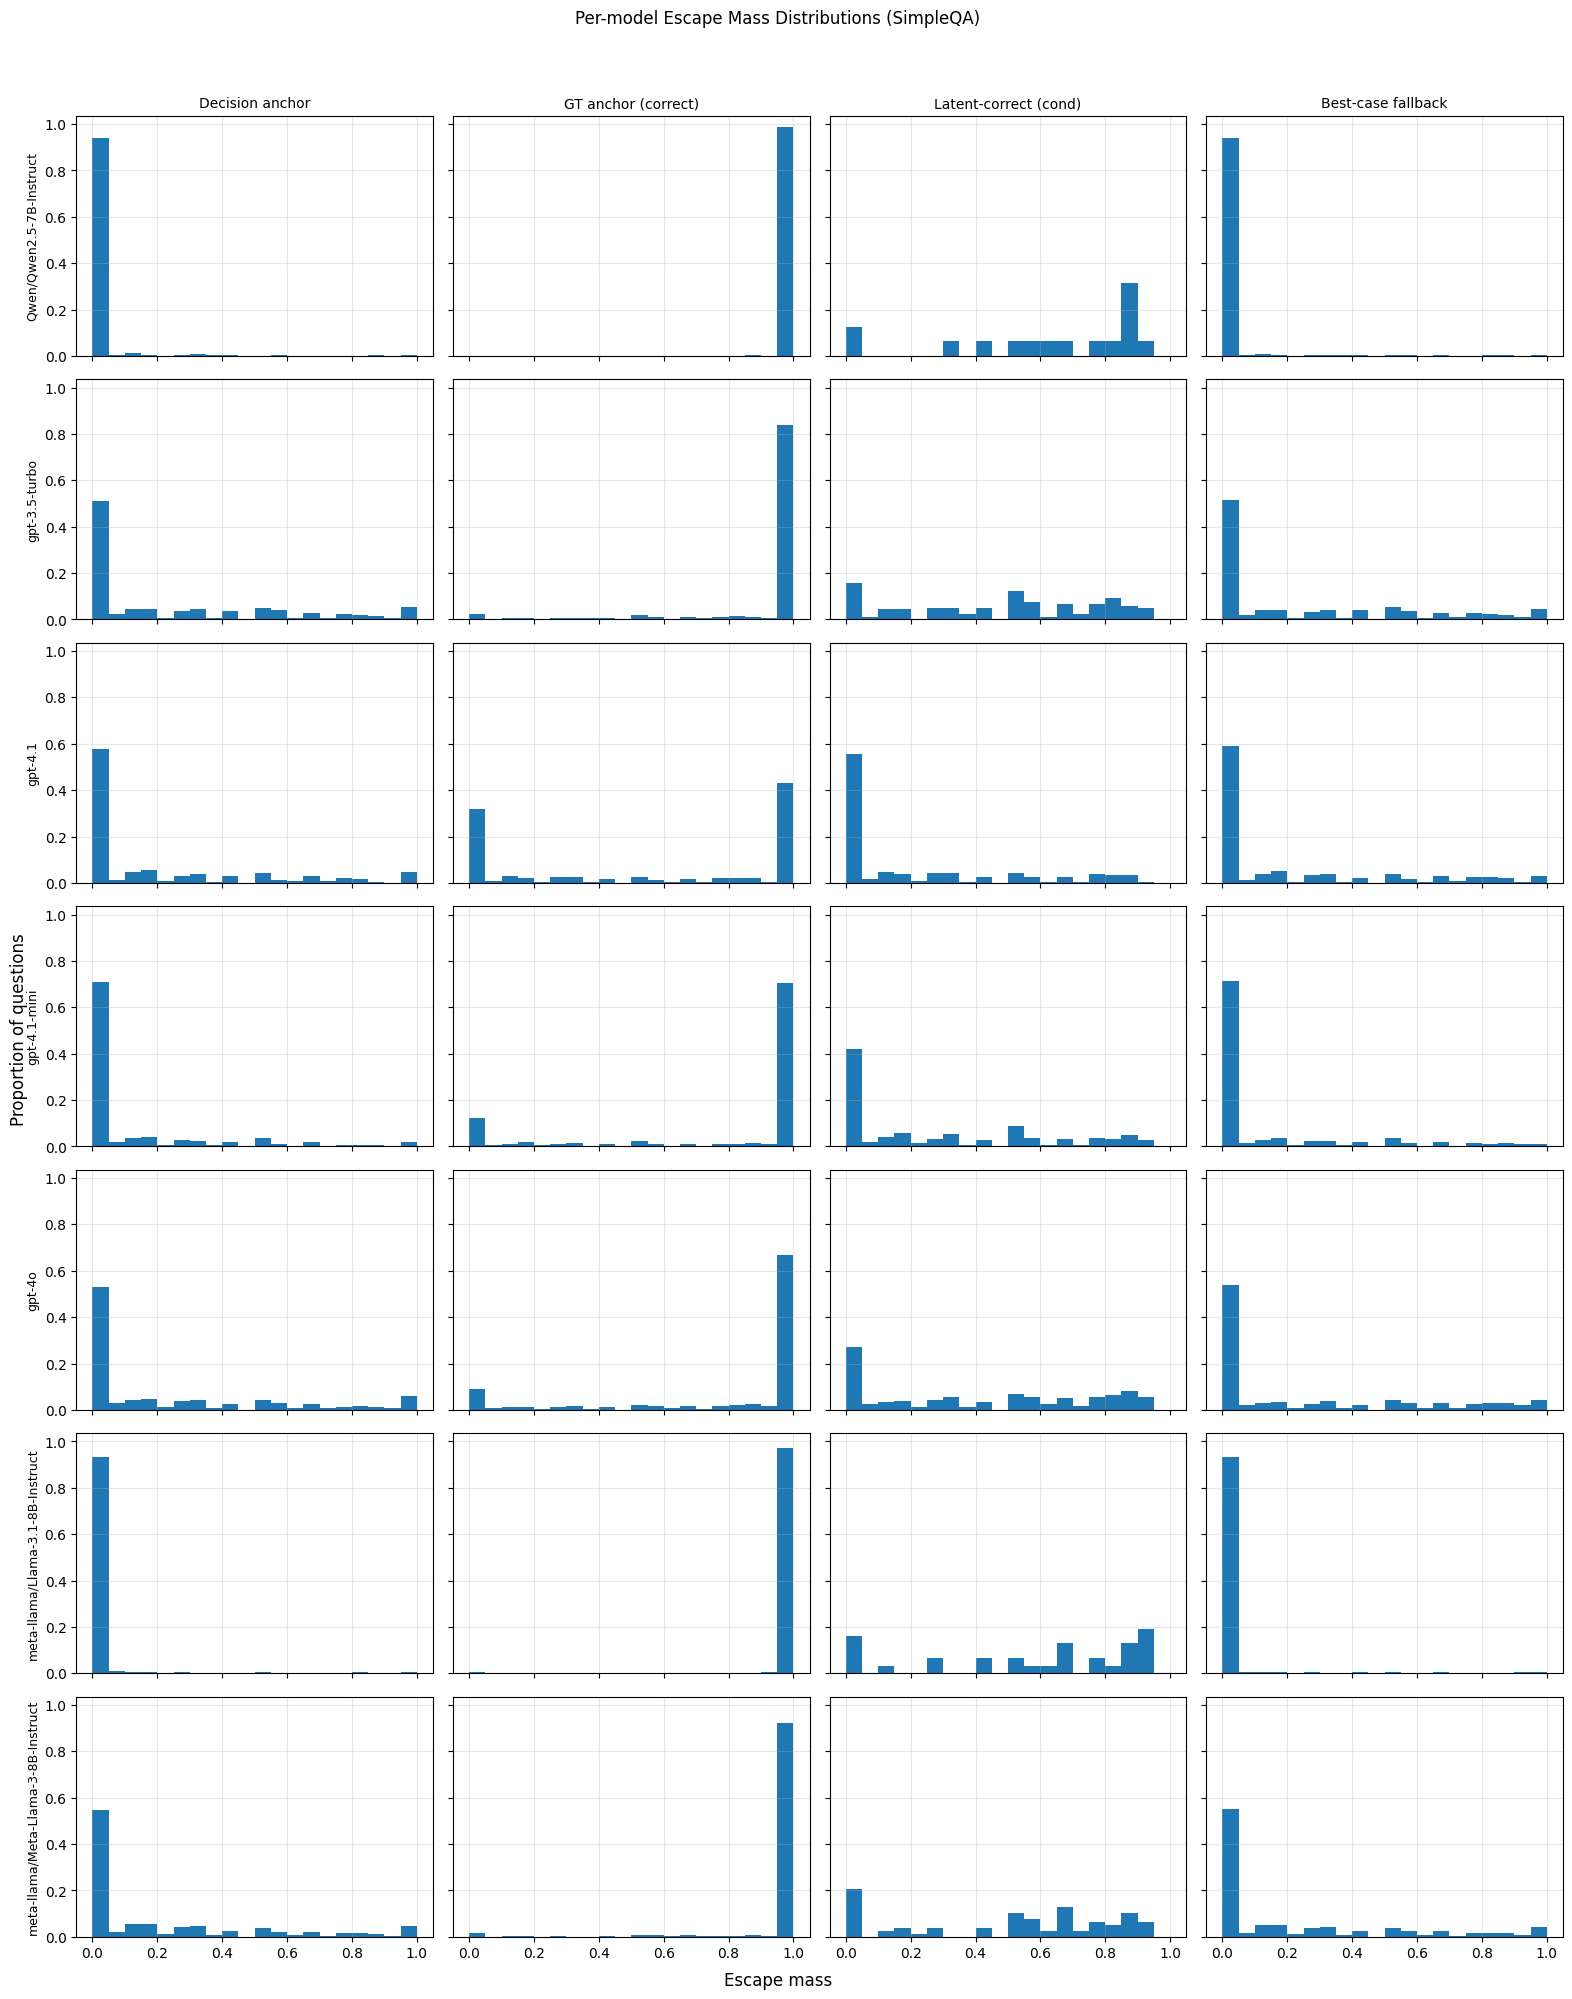

In [ ]:
plot_escape_histograms_per_model(aligned)


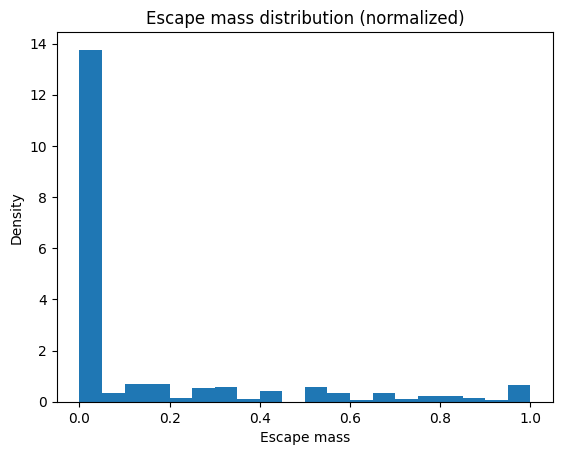

In [ ]:
bins = np.linspace(0, 1, 21)
vals = aligned["escape_decision"].dropna().to_numpy()

plt.figure()
plt.hist(vals, bins=bins, density=True)
plt.xlabel("Escape mass")
plt.ylabel("Density")
plt.title("Escape mass distribution (normalized)")
plt.show()


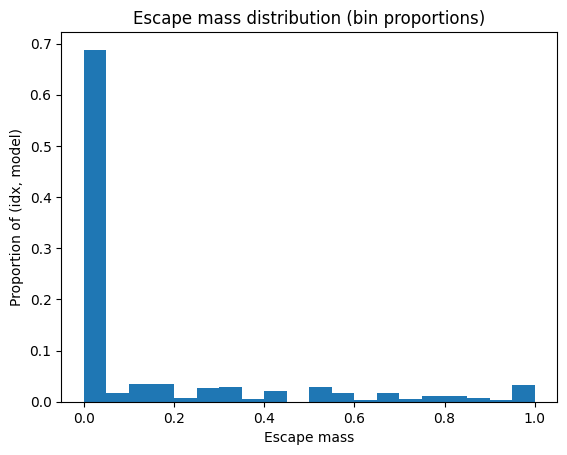

In [ ]:
bins = np.linspace(0, 1, 21)
vals = aligned["escape_decision"].dropna().to_numpy()

plt.figure()
plt.hist(vals, bins=bins, weights=np.ones_like(vals) / len(vals))
plt.xlabel("Escape mass")
plt.ylabel("Proportion of (idx, model)")
plt.title("Escape mass distribution (bin proportions)")
plt.show()


In [ ]:
import numpy as np

LABELS = ["correct","incorrect","not_attempted"]
P = aligned[[f"{l}_para" for l in LABELS]].copy()

# (A) recompute mode label + mode share from the distribution
mode_label_from_P = P.idxmax(axis=1).str.replace("_para","")
mode_share_from_P = P.max(axis=1)

# compare to your existing fields (optional)
print("para_label matches recomputed mode:",
      (aligned["para_label"] == mode_label_from_P).mean())

# (B) compute anchor share p_anchor = P(para = orig_label)
label_to_col = {l: f"{l}_para" for l in LABELS}
anchor_col = aligned["orig_label"].map(label_to_col)
col_to_i = {c:i for i,c in enumerate(P.columns)}
p_anchor = P.to_numpy()[np.arange(len(P)), anchor_col.map(col_to_i).to_numpy()]

# (C) mismatch implied by distributions: anchor is not a (tied) mode
# If ties exist, anchor could still be "a mode" even if idxmax picks something else.
eps = 1e-12
anchor_is_among_modes = np.abs(p_anchor - mode_share_from_P.to_numpy()) <= eps
mismatch_from_P = ~anchor_is_among_modes

# Compare with your stored mismatch (but ignore tie rows if you want strict equality)
mask_no_tie = ~aligned["para_is_tie"]  # you created this earlier
print("Mismatch equality on non-tie rows:",
      (aligned.loc[mask_no_tie, "match"].to_numpy() == (~mismatch_from_P[mask_no_tie])).mean())

# Also compare rates
print("stored mismatch rate:", (~aligned["match"]).mean())
print("distribution-implied mismatch rate (tie-aware):", mismatch_from_P.mean())


para_label matches recomputed mode: 1.0
Mismatch equality on non-tie rows: 1.0
stored mismatch rate: 0.11577277970011535
distribution-implied mismatch rate (tie-aware): 0.1053921568627451


In [ ]:
eps = 1e-12
P = aligned[["correct_para","incorrect_para","not_attempted_para"]]
mode_share = P.max(axis=1).to_numpy()

label_to_col = {"correct":"correct_para", "incorrect":"incorrect_para", "not_attempted":"not_attempted_para"}
anchor_col = aligned["orig_label"].map(label_to_col)

p_anchor = P.to_numpy()[np.arange(len(P)), anchor_col.map({c:i for i,c in enumerate(P.columns)}).to_numpy()]

aligned["mismatch_tieaware"] = (p_anchor + eps) < mode_share
aligned["match_tieaware"] = ~aligned["mismatch_tieaware"]


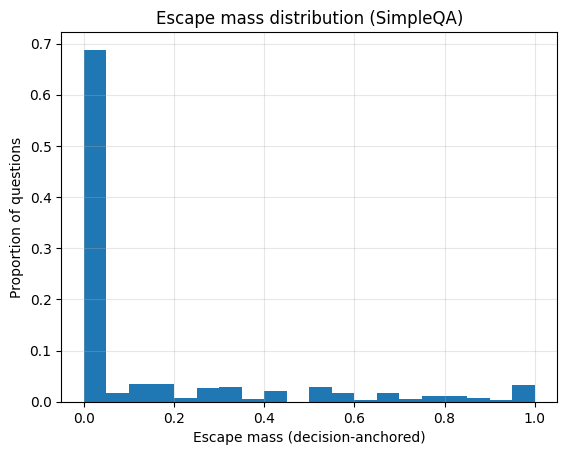

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vals = aligned["escape_decision"].dropna().to_numpy()
bins = np.linspace(0, 1, 21)

plt.figure()
plt.hist(vals, bins=bins, weights=np.ones_like(vals)/len(vals))
plt.xlabel("Escape mass (decision-anchored)")
plt.ylabel("Proportion of questions")
plt.title("Escape mass distribution (SimpleQA)")
plt.grid(True, alpha=0.3)
plt.show()


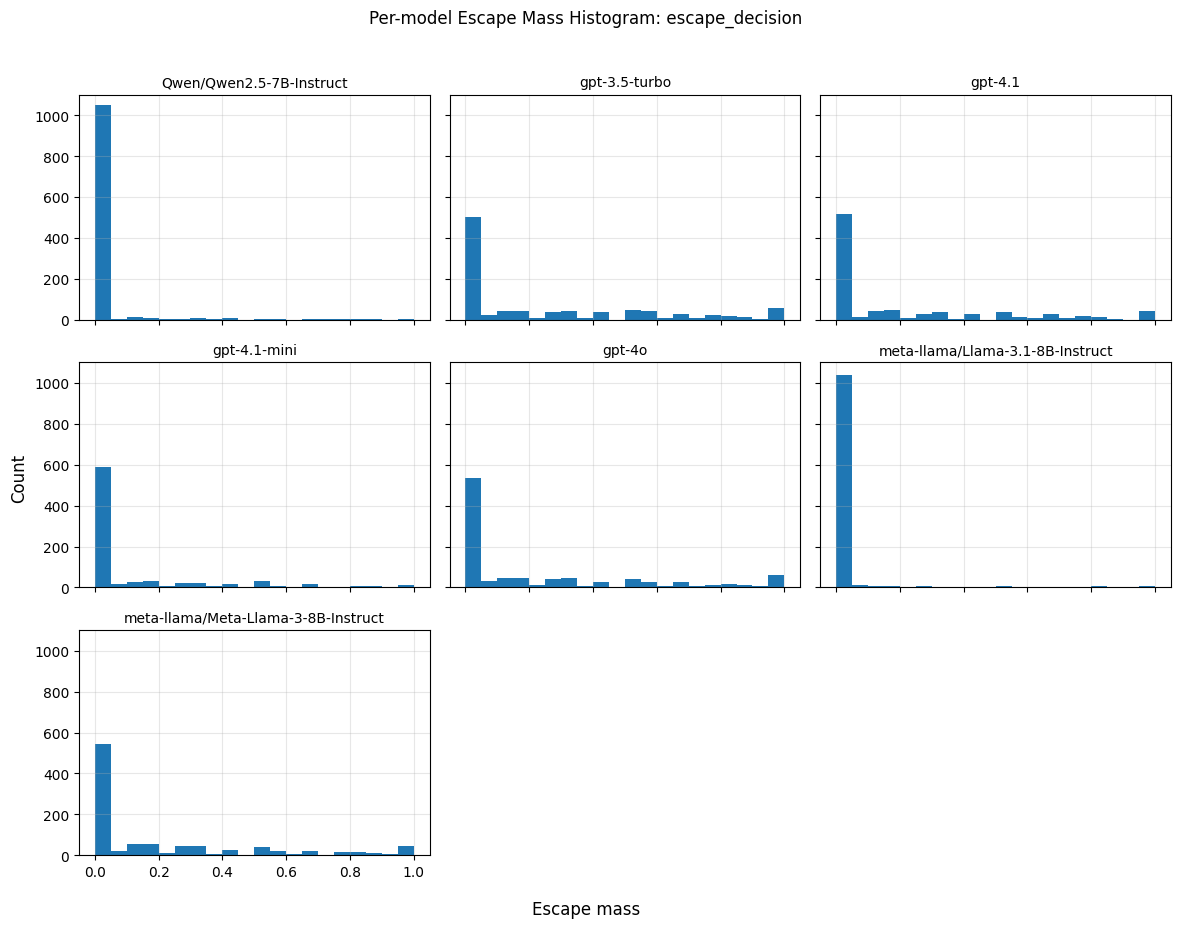

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

metric = "escape_decision"   # change to any escape_* column
bins = np.linspace(0, 1, 21)

models = sorted(aligned.reset_index()["model"].unique())

ncols = 3
nrows = math.ceil(len(models) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

df = aligned.reset_index()

for ax, m in zip(axes, models):
    vals = df.loc[df["model"] == m, metric].dropna().to_numpy()
    ax.hist(vals, bins=bins)
    ax.set_title(m, fontsize=10)
    ax.grid(True, alpha=0.3)

for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Escape mass")
fig.supylabel("Count")
fig.suptitle(f"Per-model Escape Mass Histogram: {metric}", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
pd.__version__

'2.3.3'

In [ ]:
model_name_map = {
    "gpt-4.1": "GPT-4.1",
    "gpt-4o": "GPT-4o",
    "gpt-4.1-mini": "GPT-4.1-Mini",
    "gpt-3.5-turbo": "GPT-3.5",
    "Meta-Llama-3-8B-Instruct": "LLaMA-3 8B",
    "Llama-3.1-8B-Instruct": "LLaMA-3.1 8B",
    "Qwen2.5-7B-Instruct": "Qwen-2.5 7B",
    "Qwen3-8B": "Qwen-3 8B",
    "gpt-oss-20b": "GPT-OSS 20B",
}
def shorten_model_name(name):
    return name.split("/")[-1] if "/" in name else name

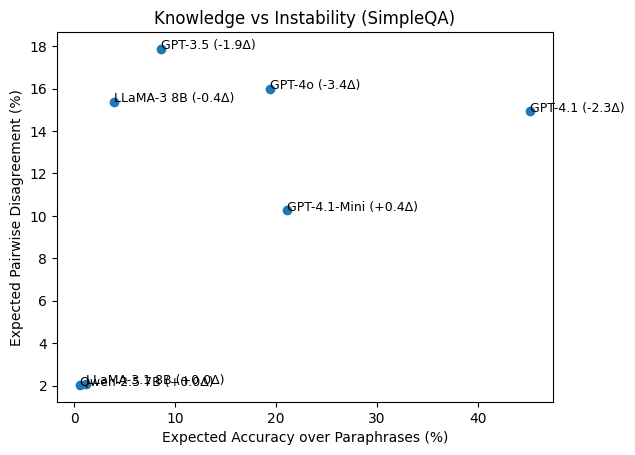

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Build plotting dataframe from your outputs ----
# agg_dist: has correct_orig, correct_para, diffs
# mismatch_stats: has iid_mismatch_prob, normalized_entropy, mismatch_rate, mode_share

plot1 = (
    agg_dist[["correct_orig", "correct_para", "diff_A"]]
    .join(mismatch_stats[["iid_mismatch_prob", "normalized_entropy", "mismatch_rate", "mode_share"]])
    .reset_index()  # brings "model" out
)
plot1['model'] = plot1['model'].apply(shorten_model_name).replace(model_name_map)
# Convert to % for readability
plot1["orig_acc_pct"] = 100 * plot1["correct_orig"].astype(float)
plot1["para_acc_pct"] = 100 * plot1["correct_para"].astype(float)
plot1["delta_acc_pct"] = 100 * (plot1["correct_para"].astype(float) - plot1["correct_orig"].astype(float))

# Convert instability metric to %
plot1["iid_mismatch_pct"] = 100 * plot1["iid_mismatch_prob"]

y_col = "iid_mismatch_pct"
y_label = "Expected Pairwise Disagreement (%)"

plt.figure()
x = plot1["para_acc_pct"].values
y = plot1[y_col].values

plt.scatter(x, y)

for _, r in plot1.iterrows():
    label = f'{r["model"]} ({r["delta_acc_pct"]:+.1f}Δ)'
    plt.text(r["para_acc_pct"], r[y_col], label, fontsize=9)

plt.xlabel("Expected Accuracy over Paraphrases (%)")
plt.ylabel(y_label)
plt.title("Knowledge vs Instability (SimpleQA)")
plt.show()

# # Choose ONE instability metric for y
# y_col = "iid_mismatch_prob"  # or "normalized_entropy" or "mismatch_rate"
# y_label = "Expected Pairwise Disagreement (IID-Mismatch)"  # adjust if you change y_col

# plt.figure()
# x = plot1["para_acc_pct"].values
# y = plot1[y_col].values

# plt.scatter(x, y)

# # Annotate points with model names
# for _, r in plot1.iterrows():
#     label = f'{r["model"]} ({r["delta_acc_pct"]:+.1f}Δ)'
#     plt.text(r["para_acc_pct"], r[y_col], label, fontsize=9)

# # for _, r in plot1.iterrows():
# #     plt.text(r["para_acc_pct"], r[y_col], r["model"], fontsize=9)

# plt.xlabel("Expected Accuracy over Paraphrases (%)")
# plt.ylabel(y_label)
# plt.title("Knowledge vs Instability (SimpleQA)")

# plt.show()


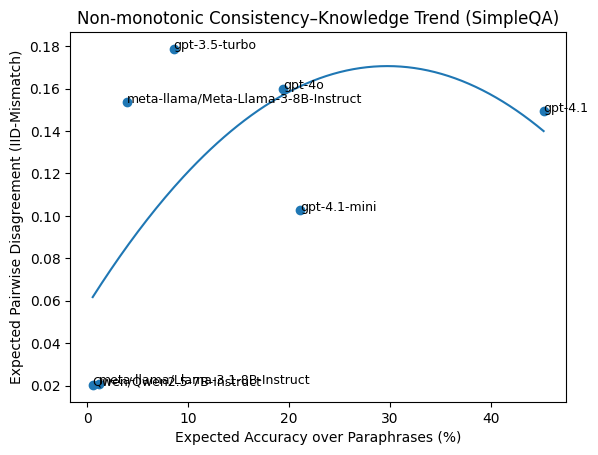

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x, y from plot1 above
x = plot1["para_acc_pct"].values
y = plot1[y_col].values

plt.figure()
plt.scatter(x, y)
for _, r in plot1.iterrows():
    plt.text(r["para_acc_pct"], r[y_col], r["model"], fontsize=9)

# Quadratic fit: y ≈ ax^2 + bx + c
# NOTE: with only ~7 points, this is illustrative, not a strong statistical claim.
coef = np.polyfit(x, y, deg=2)
xx = np.linspace(x.min(), x.max(), 200)
yy = np.polyval(coef, xx)
plt.plot(xx, yy)

plt.xlabel("Expected Accuracy over Paraphrases (%)")
plt.ylabel(y_label)
plt.title("Non-monotonic Consistency–Knowledge Trend (SimpleQA)")
plt.show()


/tmp/ipykernel_867518/249717193.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve = df_q.groupby("acc_bin")[y_qcol].mean().reset_index()


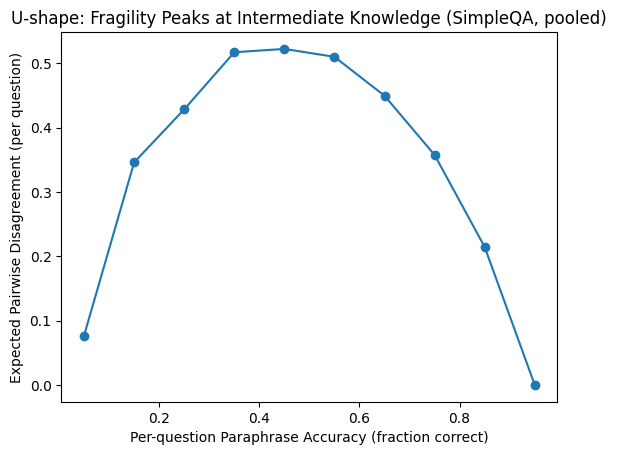

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For each question (row), we need:
# x_i: correctness fraction over paraphrases (0..1)
# y_i: instability for that question (entropy or pairwise mismatch prob)
# aligned seems to have normalized_entropy, iid_mismatch_prob per row.

df_q = aligned.reset_index()[["model", "correct_para", "iid_mismatch_prob", "normalized_entropy"]].copy()

# Choose which y to use
y_qcol = "iid_mismatch_prob"
y_qlabel = "Expected Pairwise Disagreement (per question)"

# Bin x into deciles
bins = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins, include_lowest=True)

# Aggregate within bins (option 1: across all models)
curve = df_q.groupby("acc_bin")[y_qcol].mean().reset_index()
curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

plt.figure()
plt.plot(curve["bin_center"], curve[y_qcol], marker="o")
plt.xlabel("Per-question Paraphrase Accuracy (fraction correct)")
plt.ylabel(y_qlabel)
plt.title("U-shape: Fragility Peaks at Intermediate Knowledge (SimpleQA, pooled)")
plt.show()


/tmp/ipykernel_867518/1630434884.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_867518/1630434884.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_867518/1630434884.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby("acc_bin")[y_qcol]
/tmp/ipykernel_867518/1630434884.py:27: FutureWarning: The default of obs

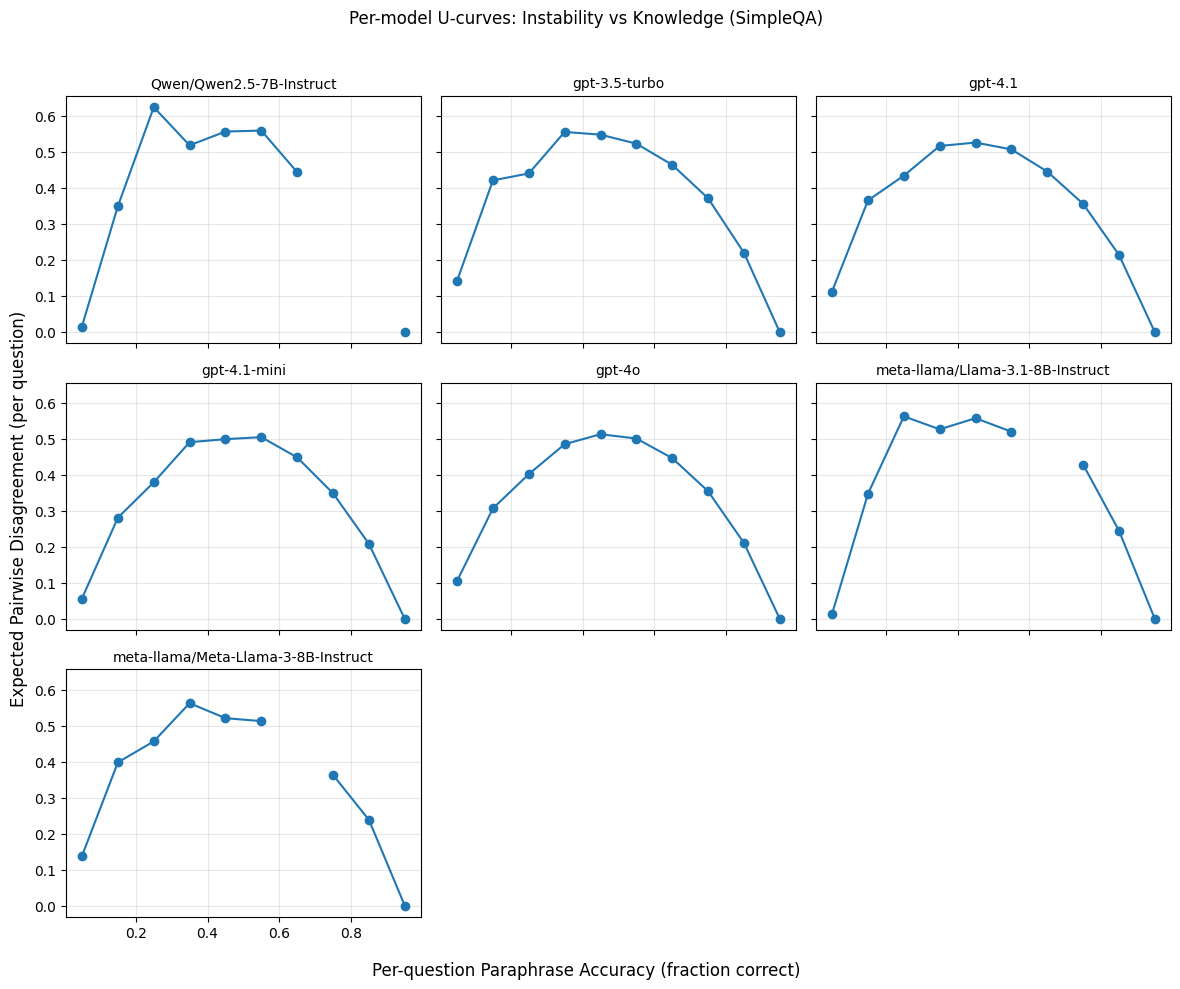

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

df_q = aligned.reset_index()[["model", "correct_para", "iid_mismatch_prob", "normalized_entropy"]].copy()

y_qcol = "iid_mismatch_prob"
y_qlabel = "Expected Pairwise Disagreement (per question)"

bins = np.linspace(0, 1, 11)
df_q["acc_bin"] = pd.cut(df_q["correct_para"].astype(float), bins=bins, include_lowest=True)

models = sorted(df_q["model"].unique())

n = len(models)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, models):
    sub = df_q[df_q["model"] == m]

    curve = (
        sub.groupby("acc_bin")[y_qcol]
           .mean()
           .reset_index()
    )
    curve["bin_center"] = curve["acc_bin"].apply(lambda x: (x.left + x.right) / 2)

    ax.plot(curve["bin_center"], curve[y_qcol], marker="o")
    ax.set_title(m, fontsize=10)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(len(models), len(axes)):
    axes[j].axis("off")

fig.supxlabel("Per-question Paraphrase Accuracy (fraction correct)")
fig.supylabel(y_qlabel)
fig.suptitle("Per-model U-curves: Instability vs Knowledge (SimpleQA)", y=1.02)
plt.tight_layout()
plt.show()


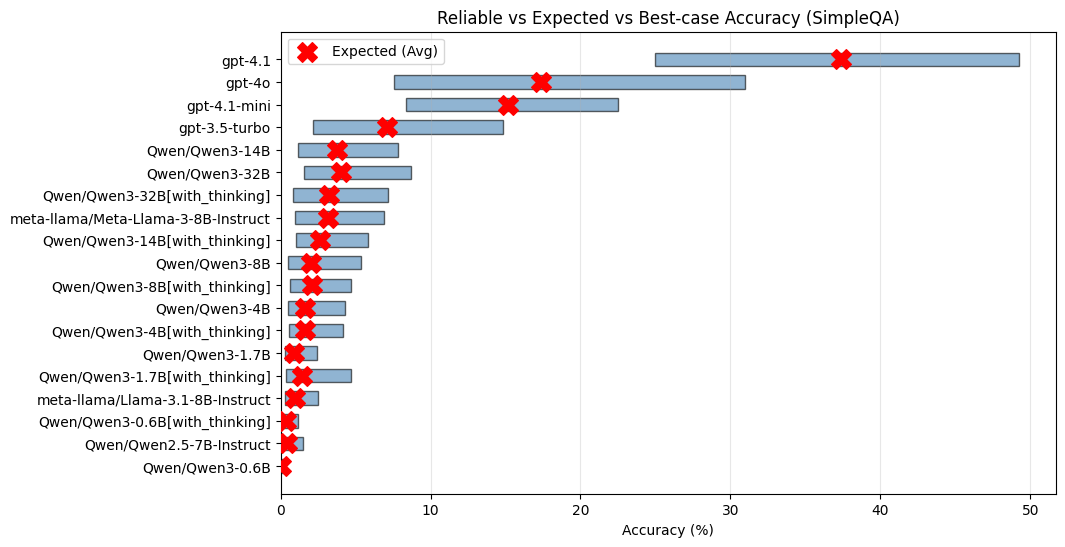

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_Aany has:
# Orig_Acc, Para_Acc, A_any_all, reliable_A (all already in %)

plot3 = df_Aany.copy()
plot3 = plot3.sort_values("Orig_Acc", ascending=True)  # nicer for horizontal plotting

models = plot3["model"].tolist()
y = np.arange(len(models))

reliable = plot3["reliable_A"].values
expected = plot3["Para_Acc"].values
bestcase = plot3["A_any_all"].values

plt.figure(figsize=(10, 6))
# Draw horizontal rectangles from reliable -> bestcase
widths = bestcase - reliable
plt.barh(y, widths, left=reliable, height=0.6, alpha=0.6, color='steelblue', edgecolor='black')
# Mark expected value as a knot (X marker)
plt.scatter(expected, y, marker='X', s=200, color='red', zorder=5, label='Expected (Avg)')

plt.yticks(y, models)
plt.xlabel("Accuracy (%)")
plt.title("Reliable vs Expected vs Best-case Accuracy (SimpleQA)")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()


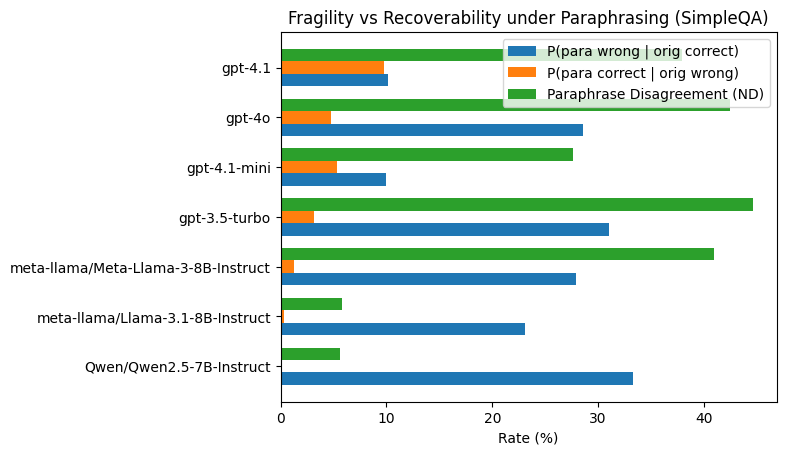

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot4 = df_flip.copy().sort_values("Orig_Acc", ascending=True)

models = plot4["model"].tolist()
y = np.arange(len(models))

fragile = plot4["A_to_notA"].values
recover = plot4["notA_to_A"].values
nd = plot4["ND"].values

plt.figure()
# Simple horizontal bar layout using offsets
h = 0.25
plt.barh(y - h, fragile, height=h, label="P(para wrong | orig correct)")
plt.barh(y,     recover, height=h, label="P(para correct | orig wrong)")
plt.barh(y + h, nd,      height=h, label="Paraphrase Disagreement (ND)")

plt.yticks(y, models)
plt.xlabel("Rate (%)")
plt.title("Fragility vs Recoverability under Paraphrasing (SimpleQA)")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Filter idx_model_vals by answer length threshold
answer_length_threshold = 60  # characters; adjust as needed
idx_model_vals = aligned.reset_index().query(query)[['idx', 'model']]
# Convert idx_model_vals to DataFrame for easier filtering
df_idx_model = pd.DataFrame(idx_model_vals, columns=['idx', 'model'])

# Get answers for these (idx, model) pairs
ans_for_pairs = ans.merge(
    df_idx_model,
    on=['idx', 'model'],
    how='inner'
)

# Compute answer lengths
ans_for_pairs["answer_length"] = ans_for_pairs["answer"].fillna("").str.len()

# Group by (idx, model) and get max answer length
max_ans_length_by_pair = ans_for_pairs.groupby(["idx", "model"])["answer_length"].max()

# Filter to keep only pairs where max answer is below threshold
filtered_pairs = max_ans_length_by_pair[max_ans_length_by_pair < answer_length_threshold].index.tolist()

print(f"Original (idx, model) pairs: {len(df_idx_model)}")
print(f"Pairs with all answers < {answer_length_threshold} chars: {len(filtered_pairs)}")
print(f"Filtered out: {len(df_idx_model) - len(filtered_pairs)}")
print(f"Percentage kept: {100 * len(filtered_pairs) / len(df_idx_model):.1f}%")

# Convert back to array format if needed
idx_model_vals_filtered = np.array(filtered_pairs)

print(f"\nFiltered idx_model_vals shape: {idx_model_vals_filtered.shape}")
print(idx_model_vals_filtered)


Original (idx, model) pairs: 149
Pairs with all answers < 60 chars: 3
Filtered out: 146
Percentage kept: 2.0%

Filtered idx_model_vals shape: (3, 2)
[['533' 'gpt-3.5-turbo']
 ['819' 'gpt-4o']
 ['1417' 'gpt-4o']]
